# **Module 2 (Emotion Classifier)**

**Dataset:** dair-ai/emotion (unsplit configuration)

**Task:** Multi-class emotion classification (6 emotion classes)

**Architecture:** Fine-tuned distilbert-base-multilingual-cased  

---

## **Part 1: Exploratory Data Analysis**

This part performs deep EDA before any modeling decisions are finalized

**Questions this EDA answers:**
1. What is the class distribution (is the dataset balanced or skewed)?
2. What is the text length distribution per emotion class?
3. Which emotion pairs overlap most in vocabulary (hardest to distinguish)?
4. What are the most discriminative words per emotion class?
5. What is the label noise level (are there visibly mislabeled samples)?
6. What does the pipeline integration look like (how does emotion feed the LLM)?

## 1. Environment Setup

In [1]:
import torch
print(torch.cuda.is_available())          
print(torch.cuda.get_device_name(0))     

True
NVIDIA A100-SXM4-40GB


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
from collections import Counter
from itertools import combinations

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.patches import Patch
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'font.family'       : 'DejaVu Sans'
})

## 2. Emotion Metadata

Defining the emotion classes with their mental health significance and pipeline role.  
This metadata is used throughout EDA and carries forward into the LLM prompt design in Module 4.

In [3]:
EMOTION_META = {
    0: {
        'name'            : 'sadness',
        'color'           : '#4C72B0',
        'mh_significance' : 'Depression signal — highest clinical risk',
        'response_tone'   : 'Warm, validating, gentle — avoid minimizing'
    },
    1: {
        'name'            : 'joy',
        'color'           : '#55A868',
        'mh_significance' : 'Positive state — reinforce and sustain',
        'response_tone'   : 'Encouraging, celebratory, engaging'
    },
    2: {
        'name'            : 'love',
        'color'           : '#C44E52',
        'mh_significance' : 'Connection-seeking — social support signal',
        'response_tone'   : 'Warm, affirming, relationship-focused'
    },
    3: {
        'name'            : 'anger',
        'color'           : '#DD8452',
        'mh_significance' : 'Frustration or distress — needs de-escalation',
        'response_tone'   : 'Calm, empathetic, non-confrontational'
    },
    4: {
        'name'            : 'fear',
        'color'           : '#8172B2',
        'mh_significance' : 'Anxiety signal — very common in mental health context',
        'response_tone'   : 'Reassuring, grounding, structured'
    },
    5: {
        'name'            : 'surprise',
        'color'           : '#937860',
        'mh_significance' : 'Neutral-to-positive — low clinical risk',
        'response_tone'   : 'Curious, engaged, open'
    }
}

LABEL_TO_NAME  = {k: v['name']  for k, v in EMOTION_META.items()}
LABEL_TO_COLOR = {k: v['color'] for k, v in EMOTION_META.items()}
NAME_TO_LABEL  = {v['name']: k  for k, v in EMOTION_META.items()}

print("Emotion classes and their mental health pipeline role:\n")
for label, meta in EMOTION_META.items():
    print(f"  [{label}] {meta['name']:<10} | {meta['mh_significance']}")
    print(f"           Response tone : {meta['response_tone']}")
    print()

Emotion classes and their mental health pipeline role:

  [0] sadness    | Depression signal — highest clinical risk
           Response tone : Warm, validating, gentle — avoid minimizing

  [1] joy        | Positive state — reinforce and sustain
           Response tone : Encouraging, celebratory, engaging

  [2] love       | Connection-seeking — social support signal
           Response tone : Warm, affirming, relationship-focused

  [3] anger      | Frustration or distress — needs de-escalation
           Response tone : Calm, empathetic, non-confrontational

  [4] fear       | Anxiety signal — very common in mental health context
           Response tone : Reassuring, grounding, structured

  [5] surprise   | Neutral-to-positive — low clinical risk
           Response tone : Curious, engaged, open



## 3. Load Dataset

In [4]:
# Using unsplit config for maximum training data (416k vs 16k in split config)
raw_unsplit = load_dataset('dair-ai/emotion', 'unsplit')
raw_split   = load_dataset('dair-ai/emotion', 'split')

# Full dataset for EDA (no leakage risk at this stage)
full_df = raw_unsplit['train'].to_pandas()

# Split config for understanding the predefined benchmark splits
split_train_df = raw_split['train'].to_pandas()
split_val_df   = raw_split['validation'].to_pandas()
split_test_df  = raw_split['test'].to_pandas()

# Enrich with human-readable labels
full_df['emotion']       = full_df['label'].map(LABEL_TO_NAME)
full_df['emotion_color'] = full_df['label'].map(LABEL_TO_COLOR)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

unsplit/train-00000-of-00001.parquet:   0%|          | 0.00/26.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/416809 [00:00<?, ? examples/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
print(f"Unsplit config total samples : {len(full_df):,}")
print(f"Split config (train)         : {len(split_train_df):,}")
print(f"Split config (val)         : {len(split_val_df):,}")
print(f"Split config (test)         : {len(split_test_df):,}")
print(f"\nSchema : {list(full_df.columns)}")
print(f"Labels : {sorted(full_df['label'].unique().tolist())}")
full_df.head(8)

Unsplit config total samples : 416,809
Split config (train)         : 16,000
Split config (val)         : 2,000
Split config (test)         : 2,000

Schema : ['text', 'label', 'emotion', 'emotion_color']
Labels : [0, 1, 2, 3, 4, 5]


,text,label,emotion,emotion_color
0,i feel awful about it too because it s my job ...,0,sadness,#4C72B0
1,im alone i feel awful,0,sadness,#4C72B0
2,ive probably mentioned this before but i reall...,1,joy,#55A868
3,i was feeling a little low few days back,0,sadness,#4C72B0
4,i beleive that i am much more sensitive to oth...,2,love,#C44E52
5,i find myself frustrated with christians becau...,2,love,#C44E52
6,i am one of those people who feels like going ...,1,joy,#55A868
7,i feel especially pleased about this as this h...,1,joy,#55A868


## 4. Question 1 (Class Distribution)

Emotion datasets from social media are typically heavily skewed.

This directly determines metric choice and training strategy.

In [6]:
class_counts = full_df['emotion'].value_counts()
class_pct    = (class_counts / len(full_df) * 100).round(2)

dist_df = pd.DataFrame({
    'emotion'    : class_counts.index,
    'count'      : class_counts.values,
    'percentage' : class_pct.values
})

dist_df['color']           = dist_df['emotion'].map({v['name']: v['color'] for v in EMOTION_META.values()})
dist_df['mh_significance'] = dist_df['emotion'].map({v['name']: v['mh_significance'] for v in EMOTION_META.values()})
imbalance_ratio = class_counts.max() / class_counts.min()

In [7]:
print(f"Class distribution in unsplit config ({len(full_df):,} total samples):\n")
for _, row in dist_df.iterrows():
    bar = '█' * int(row['percentage'] / 1)
    print(f"  {row['emotion']:<10} : {row['count']:>7,} ({row['percentage']:>5.2f}%)  {bar}")

print(f"\nImbalance ratio (max/min) : {imbalance_ratio:.2f}x")
print(f"Most frequent class       : {class_counts.idxmax()} ({class_counts.max():,})")
print(f"Least frequent class      : {class_counts.idxmin()} ({class_counts.min():,})")

Class distribution in unsplit config (416,809 total samples):

  joy        : 141,067 (33.84%)  █████████████████████████████████
  sadness    : 121,187 (29.07%)  █████████████████████████████
  anger      :  57,317 (13.75%)  █████████████
  fear       :  47,712 (11.45%)  ███████████
  love       :  34,554 ( 8.29%)  ████████
  surprise   :  14,972 ( 3.59%)  ███

Imbalance ratio (max/min) : 9.42x
Most frequent class       : joy (141,067)
Least frequent class      : surprise (14,972)


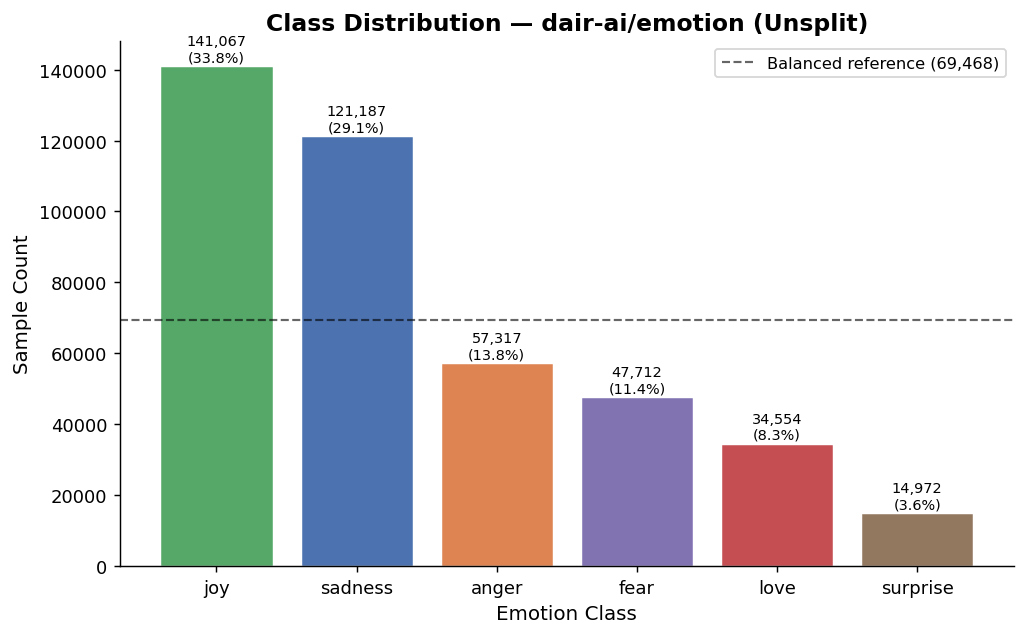

Saved: eda2_01_class_distribution.png


In [8]:
fig, ax = plt.subplots(figsize = (8, 5))
bars = ax.bar(
    dist_df['emotion'],
    dist_df['count'],
    color     = dist_df['color'],
    edgecolor = 'white',
    linewidth = 0.8
)


# Balanced reference line (what counts would look like if perfectly balanced)
balanced_count = len(full_df) / len(EMOTION_META)
ax.axhline(
    balanced_count,
    color     = 'black',
    linestyle = '--',
    linewidth = 1.2,
    alpha     = 0.6,
    label     = f'Balanced reference ({balanced_count:,.0f})'
)

for bar, (_, row) in zip(bars, dist_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{row['count']:,}\n({row['percentage']:.1f}%)",
        ha       = 'center',
        va       = 'bottom',
        fontsize = 8
    )


ax.set_xlabel('Emotion Class')
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution — dair-ai/emotion (Unsplit)', fontweight = 'bold')
ax.legend(fontsize = 9)
plt.tight_layout()
plt.savefig('eda2_01_class_distribution.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_01_class_distribution.png")

In [9]:
# Compare split vs unsplit distribution to verify consistency
split_counts = split_train_df['label'].map(LABEL_TO_NAME).value_counts()
split_pct    = (split_counts / len(split_train_df) * 100).round(2)

comparison_df = pd.DataFrame({
    'unsplit_%' : class_pct,
    'split_%'   : split_pct
}).round(2)

In [10]:
comparison_df['difference'] = (comparison_df['unsplit_%'] - comparison_df['split_%']).round(2)
print("Distribution comparison: unsplit vs split train config")
print()
display(
    comparison_df
    .style
    .format('{:.2f}%')
    .background_gradient(subset = ['difference'], cmap = 'RdYlGn', vmin = -5, vmax = 5)
    .set_caption("Class Distribution: Unsplit vs Split Config")
    .set_properties(**{'text-align': 'center'})
)

Distribution comparison: unsplit vs split train config



,unsplit_%,split_%,difference
joy,33.84%,33.51%,0.33%
sadness,29.07%,29.16%,-0.09%
anger,13.75%,13.49%,0.26%
fear,11.45%,12.11%,-0.66%
love,8.29%,8.15%,0.14%
surprise,3.59%,3.58%,0.01%


## 5. Question 2 (Text Length Distribution per Emotion)

Text length affects tokenization strategy and model input design.  
DistilBERT has a 512 token limit so we must verify no truncation is needed.  
Length differences across emotions may also reveal annotation patterns.

In [11]:
full_df['char_len'] = full_df['text'].str.len()
full_df['word_len'] = full_df['text'].str.split().str.len()

length_stats = (
    full_df.groupby('emotion')[['char_len', 'word_len']]
    .agg(['mean', 'median', 'min', 'max', 'std'])
    .round(1)
)

print("Text length statistics per emotion class (character level):")
print(length_stats['char_len'].sort_values('mean', ascending = False).to_string())
print()
print("Text length statistics per emotion class (word level):")
print(length_stats['word_len'].sort_values('mean', ascending = False).to_string())

Text length statistics per emotion class (character level):
           mean  median  min  max   std
emotion                                
love      104.7    94.0   10  300  56.7
surprise   99.7    89.0   12  299  55.9
joy        98.7    88.0    4  470  55.7
fear       96.7    85.0    2  411  56.3
anger      96.0    84.0    2  830  57.1
sadness    93.1    81.0    2  525  55.9

Text length statistics per emotion class (word level):
          mean  median  min  max   std
emotion                               
love      20.8    19.0    3   71  11.2
surprise  19.7    18.0    3   66  11.0
joy       19.5    17.0    1   94  10.9
anger     19.0    17.0    1  178  11.3
fear      19.0    17.0    1   79  11.1
sadness   18.5    16.0    1  101  11.0


In [12]:
# Estimate token length (approximate: 1 word ≈ 1.3 tokens for English)
full_df['approx_tokens'] = (full_df['word_len'] * 1.3).astype(int)

over_512   = (full_df['approx_tokens'] > 512).sum()
over_256   = (full_df['approx_tokens'] > 256).sum()
over_128   = (full_df['approx_tokens'] > 128).sum()

print(f"Token length analysis (approximate, 1 word ≈ 1.3 tokens):")
print(f"  Samples exceeding 512 tokens : {over_512:,}  ({over_512/len(full_df)*100:.3f}%)")
print(f"  Samples exceeding 256 tokens : {over_256:,}  ({over_256/len(full_df)*100:.3f}%)")
print(f"  Samples exceeding 128 tokens : {over_128:,}  ({over_128/len(full_df)*100:.3f}%)")
print(f"\n  Max token length observed    : {full_df['approx_tokens'].max()}")
print(f"  Mean token length            : {full_df['approx_tokens'].mean():.1f}")
print(f"  Median token length          : {full_df['approx_tokens'].median():.0f}")

Token length analysis (approximate, 1 word ≈ 1.3 tokens):
  Samples exceeding 512 tokens : 0  (0.000%)
  Samples exceeding 256 tokens : 0  (0.000%)
  Samples exceeding 128 tokens : 5  (0.001%)

  Max token length observed    : 231
  Mean token length            : 24.5
  Median token length          : 22


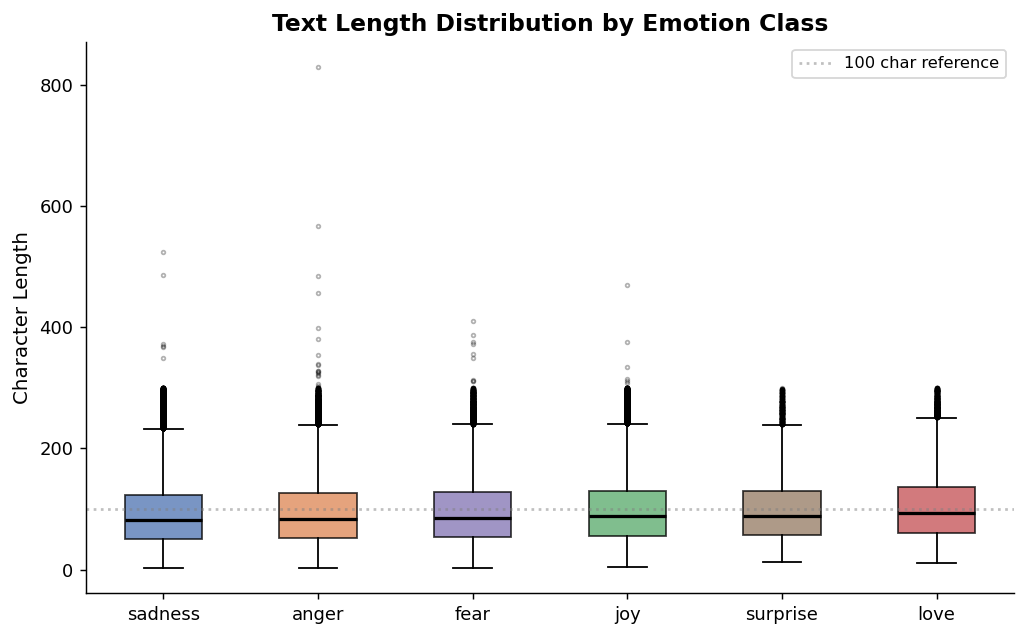

Saved: eda2_02_length_by_emotion.png


In [13]:
# Character length box plot per emotion
emotion_order = full_df.groupby('emotion')['char_len'].median().sort_values().index.tolist()
plot_data     = [full_df[full_df['emotion'] == e]['char_len'].values for e in emotion_order]
box_colors    = [EMOTION_META[NAME_TO_LABEL[e]]['color'] for e in emotion_order]

fig, ax = plt.subplots(figsize = (8, 5))
bp = ax.boxplot(
    plot_data,
    patch_artist = True,
    vert         = True,
    flierprops   = dict(marker = 'o', markersize = 2, alpha = 0.3),
    medianprops  = dict(color = 'black', linewidth = 1.8)
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)


ax.set_xticks(range(1, len(emotion_order) + 1))
ax.set_xticklabels(emotion_order, fontsize = 10)
ax.set_ylabel('Character Length')
ax.set_title('Text Length Distribution by Emotion Class', fontweight = 'bold')
ax.axhline(100, color = 'gray', linestyle = ':', alpha = 0.5, label = '100 char reference')
ax.legend(fontsize = 9)
plt.tight_layout()

plt.savefig('eda2_02_length_by_emotion.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_02_length_by_emotion.png")

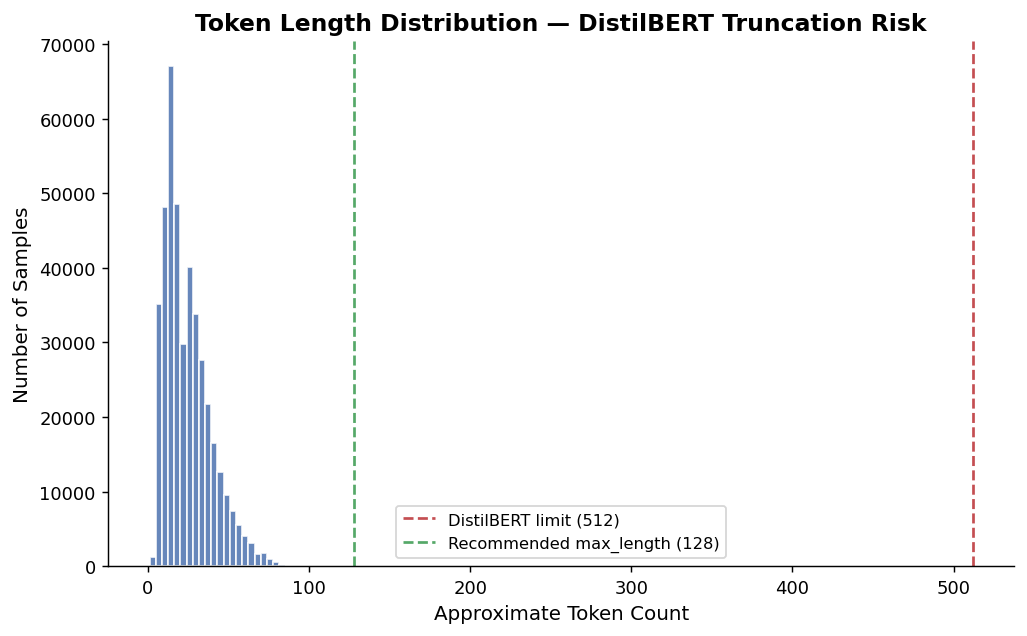

Saved: eda2_03_token_length.png


In [14]:
# Token length histogram (verify DistilBERT 512 limit is safe)
fig, ax = plt.subplots(figsize = (8, 5))

ax.hist(
    full_df['approx_tokens'],
    bins      = 60,
    color     = '#4C72B0',
    edgecolor = 'white',
    alpha     = 0.85
)
ax.axvline(512, color = '#C44E52', linestyle = '--', linewidth = 1.5, label = 'DistilBERT limit (512)')
ax.axvline(128, color = '#55A868', linestyle = '--', linewidth = 1.5, label = 'Recommended max_length (128)')
ax.set_xlabel('Approximate Token Count')
ax.set_ylabel('Number of Samples')
ax.set_title('Token Length Distribution — DistilBERT Truncation Risk', fontweight = 'bold')
ax.legend(fontsize = 9)

plt.tight_layout()
plt.savefig('eda2_03_token_length.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_03_token_length.png")

## 6. Question 3 (Vocabulary Overlap Between Emotion Classes)

Emotions that share vocabulary are harder to distinguish.  
sadness/fear and joy/love are expected to be the hardest pairs.  
This analysis drives the model architecture and augmentation decisions.

This vectorizer is used only for EDA measuring pairwise overlap between emotion classes. It is not the feature extractor for the model. The actual model (DistilBERT) does not use TF-IDF at all it uses learned contextual embeddings which are far more powerful than any TF-IDF configuration.

In [15]:
# Build one TF-IDF centroid vector per emotion class using word-level features
# Word-level overlap is more meaningful for semantic similarity than char n-grams here

emotion_corpora = (
    full_df.groupby('emotion')['text']
    .apply(lambda texts: ' '.join(texts.tolist()))
    .to_dict()
)

tfidf_overlap = TfidfVectorizer(
    analyzer    = 'word',     # word n-grams captures semantic meaning
    ngram_range = (1, 2),
    max_features = 50_000,
    sublinear_tf = True,
    stop_words  = 'english'   # remove stopwords for semantic overlap measurement
)

emotion_names_sorted = sorted(emotion_corpora.keys())
corpus_list          = [emotion_corpora[e] for e in emotion_names_sorted]
emotion_vectors      = tfidf_overlap.fit_transform(corpus_list)
similarity_matrix    = cosine_similarity(emotion_vectors)

sim_df = pd.DataFrame(
    similarity_matrix,
    index   = emotion_names_sorted,
    columns = emotion_names_sorted
)

print("Emotion centroid cosine similarity (word TF-IDF):")
print(sim_df.round(3).to_string())

Emotion centroid cosine similarity (word TF-IDF):
          anger   fear    joy   love  sadness  surprise
anger     1.000  0.685  0.664  0.638    0.700     0.596
fear      0.685  1.000  0.665  0.638    0.689     0.660
joy       0.664  0.665  1.000  0.715    0.702     0.589
love      0.638  0.638  0.715  1.000    0.641     0.612
sadness   0.700  0.689  0.702  0.641    1.000     0.578
surprise  0.596  0.660  0.589  0.612    0.578     1.000


### **Overall observation is all similarities are high (0.58–0.72)**

Every pair scores above 0.58 which is surprisingly high. This tells us one important thing the dataset texts all start with "i feel" or "i am feeling" meaning every class shares the same basic sentence structure. Even after removing stopwords the emotional vocabulary bleeds across classes significantly.


**Hardest pairs (highest similarity):**

- **joy ↔ love (0.716)**  highest overlap in the entire matrix these two emotions share words like happy, wonderful, beautiful, amazing and a user expressing love often also expresses joy and vice versa this will be the most confused pair in the model

- **joy ↔ sadness (0.702)** second highest counterintuitive but explainable as texts about sadness often contain joy words in negation like "i don't feel happy", "i wish i felt good" the vocabulary is shared even though the emotion is opposite

- **anger ↔ fear (0.685)** third highest both involve high arousal negative states and words like "overwhelmed", "terrible", "awful" appear in both

---

**Easiest pairs (lowest similarity):**

- **sadness ↔ surprise (0.577)** most separable pair surprise vocabulary is genuinely distinct

- **joy ↔ surprise (0.589)** second most separable surprise tends to be shorter and uses more exclamatory language

- **anger ↔ surprise (0.595)** third most separable

---

**The surprise pattern**

Surprise consistently shows the lowest similarity with every other class. This makes linguistic sense surprise uses unique vocabulary like "shocked", "unexpected", "wow", "unbelievable" that rarely appears in other emotional contexts. Despite being a minority class it may actually be one of the easier classes for the model to learn.

---

**Critical mental health implication**

The anger ↔ fear overlap (0.685) and sadness ↔ fear overlap (0.689) are both high. These are the three highest-risk emotions in the mental health context. When the model confuses anger with fear or sadness with fear all three trigger the elevated care response so clinically these confusions are **acceptable**. The dangerous confusion would be sadness or fear being misclassified as joy or surprise a user in distress receiving a cheerful response. From the matrix joy ↔ sadness (0.702) being the second highest overlap is the most concerning finding from a clinical perspective.

In [16]:
# Ranked pairwise similarities (hardest pairs first)
pair_sims = []
for i, j in combinations(range(len(emotion_names_sorted)), 2):
    pair_sims.append({
        'emotion_a'  : emotion_names_sorted[i],
        'emotion_b'  : emotion_names_sorted[j],
        'similarity' : similarity_matrix[i, j]
    })

pair_sim_df = pd.DataFrame(pair_sims).sort_values('similarity', ascending = False)
print("Emotion pair similarity ranking (most confusable first):")
print()
for _, row in pair_sim_df.iterrows():
    bar = '█' * int(row['similarity'] * 40)
    print(f"  {row['emotion_a']:<10} ↔ {row['emotion_b']:<10} : {row['similarity']:.4f}  {bar}")

Emotion pair similarity ranking (most confusable first):

  joy        ↔ love       : 0.7154  ████████████████████████████
  joy        ↔ sadness    : 0.7023  ████████████████████████████
  anger      ↔ sadness    : 0.6998  ███████████████████████████
  fear       ↔ sadness    : 0.6888  ███████████████████████████
  anger      ↔ fear       : 0.6854  ███████████████████████████
  fear       ↔ joy        : 0.6647  ██████████████████████████
  anger      ↔ joy        : 0.6636  ██████████████████████████
  fear       ↔ surprise   : 0.6598  ██████████████████████████
  love       ↔ sadness    : 0.6408  █████████████████████████
  fear       ↔ love       : 0.6384  █████████████████████████
  anger      ↔ love       : 0.6381  █████████████████████████
  love       ↔ surprise   : 0.6119  ████████████████████████
  anger      ↔ surprise   : 0.5963  ███████████████████████
  joy        ↔ surprise   : 0.5891  ███████████████████████
  sadness    ↔ surprise   : 0.5784  ███████████████████████


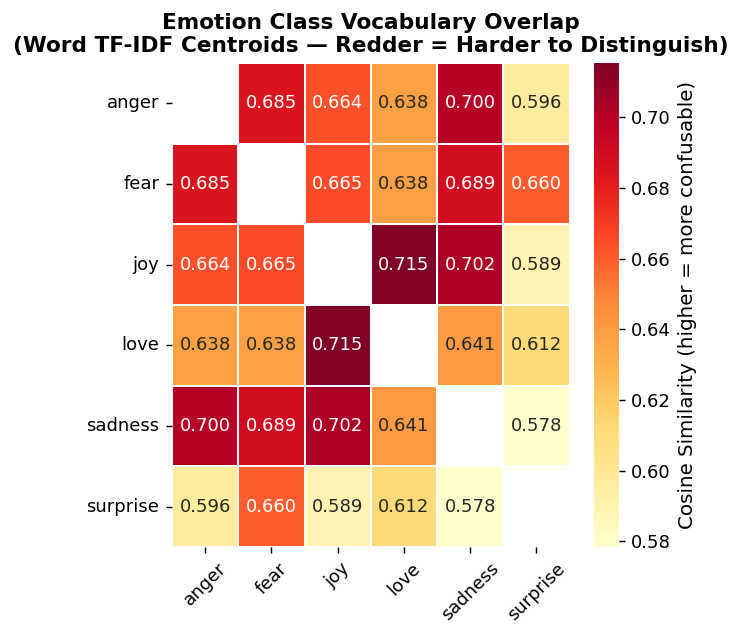

Saved: eda2_04_emotion_overlap.png


In [17]:
# Heatmap of emotion similarity
fig, ax = plt.subplots(figsize = (5, 5))

mask_diag = np.eye(len(sim_df), dtype = bool)
sns.heatmap(
    sim_df,
    ax          = ax,
    annot       = True,
    fmt         = '.3f',
    cmap        = 'YlOrRd',
    mask        = mask_diag,
    linewidths  = 1,
    linecolor   = 'white',
    annot_kws   = {'size': 10},
    cbar_kws    = {'label': 'Cosine Similarity (higher = more confusable)'}
)
ax.set_title(
    'Emotion Class Vocabulary Overlap\n(Word TF-IDF Centroids — Redder = Harder to Distinguish)',
    fontsize   = 12,
    fontweight = 'bold'
)

ax.tick_params(axis = 'x', rotation = 45)
ax.tick_params(axis = 'y', rotation = 0)
plt.tight_layout()
plt.savefig('eda2_04_emotion_overlap.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_04_emotion_overlap.png")

## 7. Question 4 (Most Discriminative Words per Emotion)

Top TF-IDF words per emotion reveal what vocabulary the model will use to distinguish classes.

This validates whether the dataset is linguistically coherent and exposes potential label noise.

In [18]:
feature_names = tfidf_overlap.get_feature_names_out()

print("Top 15 most discriminative words per emotion class:\n")
for i, emotion in enumerate(emotion_names_sorted):
    top_idx    = emotion_vectors[i].toarray().flatten().argsort()[-15:][::-1]
    top_words  = [feature_names[idx] for idx in top_idx]
    label_id   = NAME_TO_LABEL[emotion]
    print(f"  [{label_id}] {emotion:<10} : {', '.join(top_words)}")

Top 15 most discriminative words per emotion class:

  [3] anger      : feel wronged, feel rushed, feel rude, feeling grumpy, feeling cranky, feel bothered, feeling irritable, feel irritable, feel violent, feel fucked, feeling bitchy, feel outraged, feel bitchy, feeling envious, feel rebellious
  [4] fear       : feel reluctant, feel hesitant, feel shaky, feeling shaky, feel frantic, feeling terrified, feeling paranoid, feel apprehensive, feel doubtful, feeling shy, feeling doubtful, feeling distressed, feeling frantic, feeling reluctant, feeling hesitant
  [1] joy        : feel honoured, feel assured, feeling adventurous, feel respected, feeling festive, feel vital, feel successful, feeling brave, feel terrific, feel intelligent, feel fabulous, feel acceptable, feel thrilled, feel divine, feel gorgeous
  [2] love       : feeling nostalgic, feel loyal, feel naughty, feeling horny, feel compassionate, feel delicate, feeling sympathetic, feeling tender, feel sympathetic, feeling generous

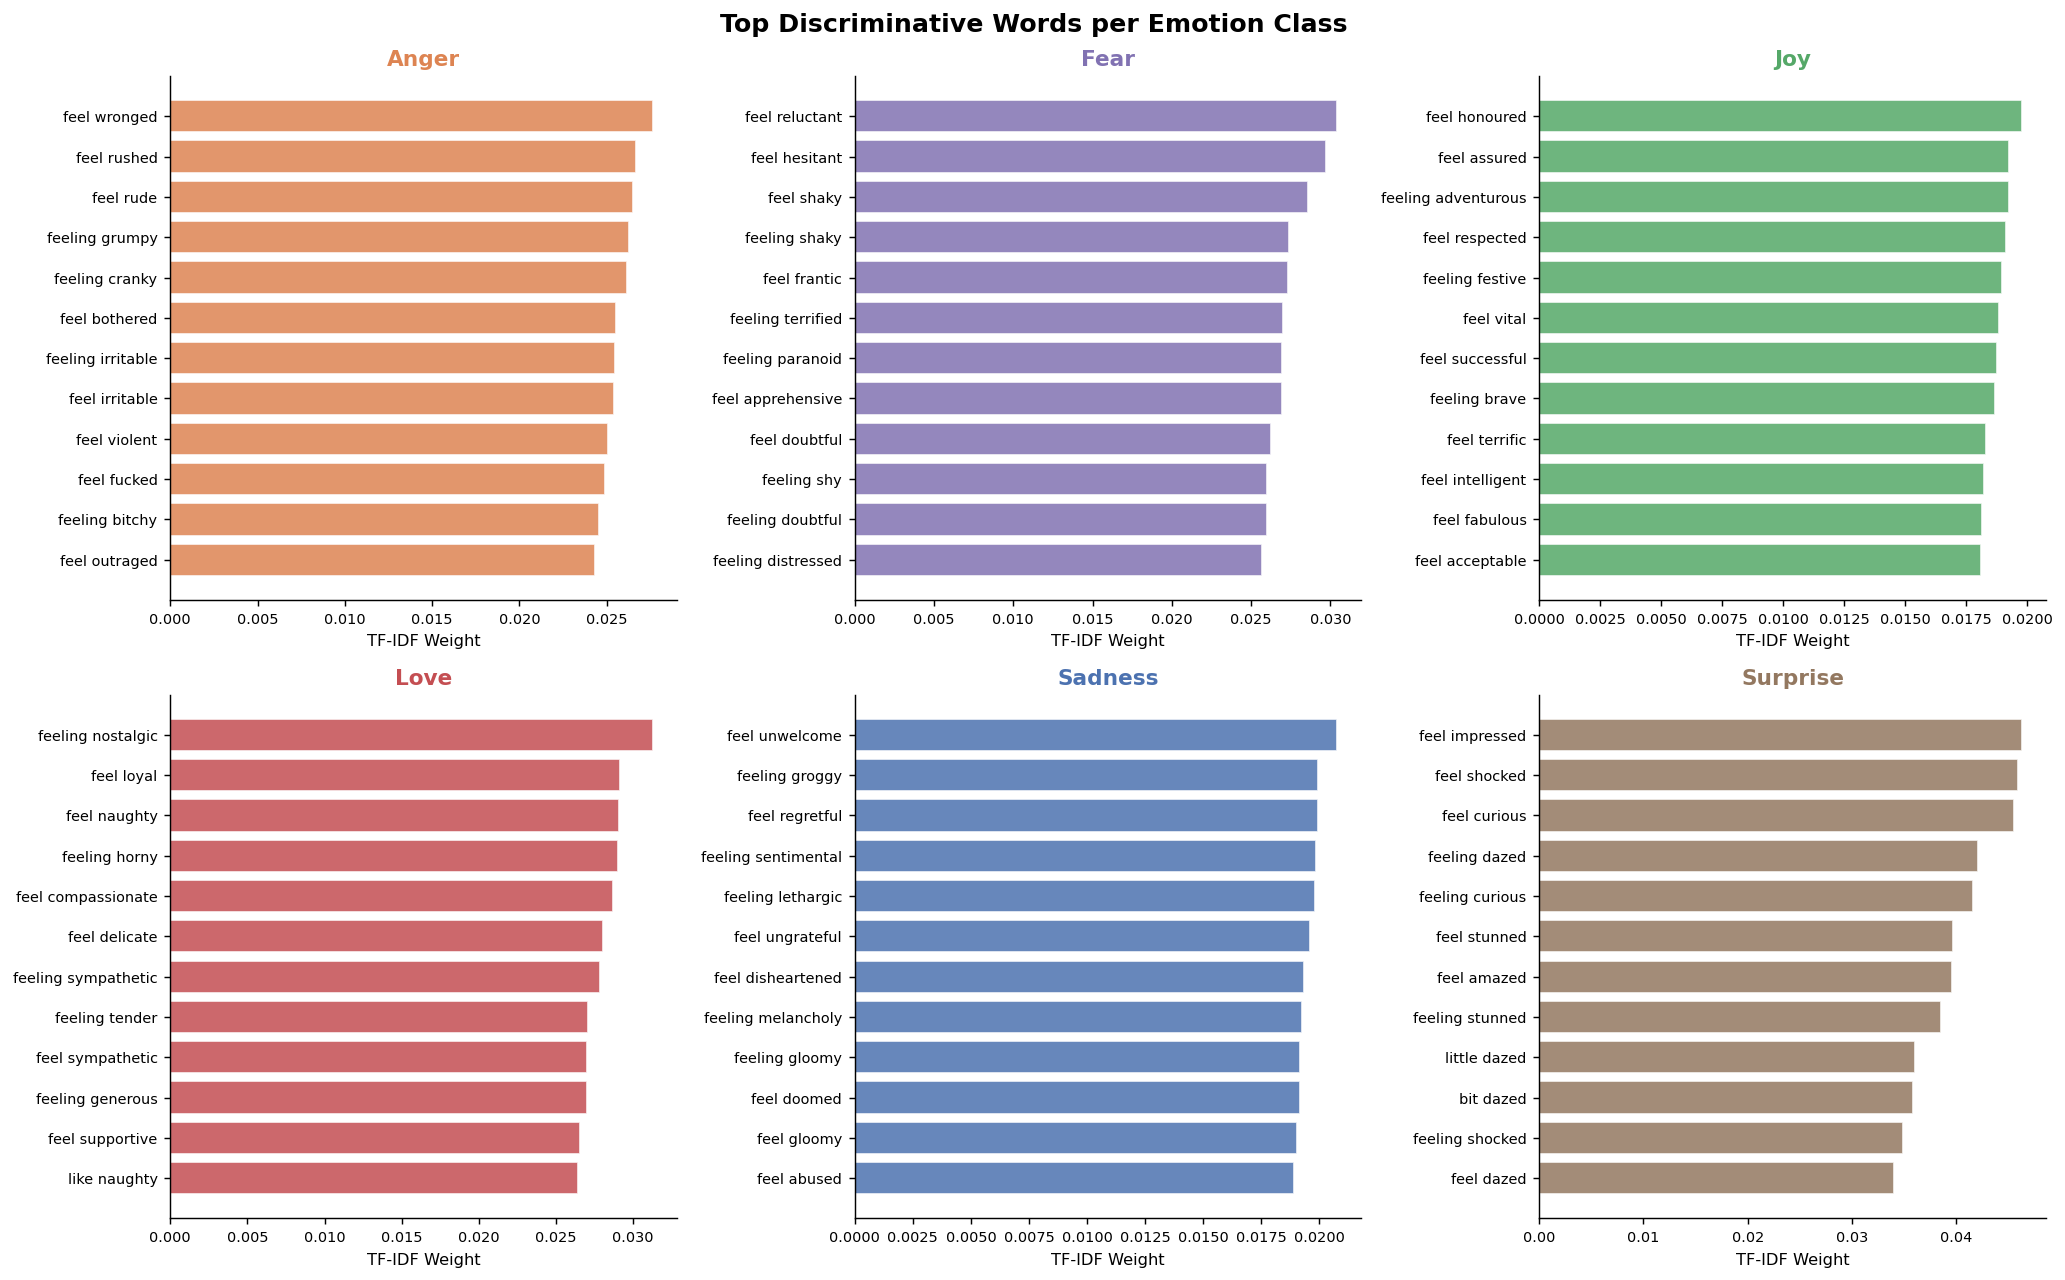

Saved: eda2_05_top_words.png


In [19]:
# Visualize top discriminative words per emotion
fig, axes = plt.subplots(2, 3, figsize = (16, 10))
axes      = axes.flatten()

for i, emotion in enumerate(emotion_names_sorted):
    weights   = emotion_vectors[i].toarray().flatten()
    top_idx   = weights.argsort()[-12:][::-1]
    top_words = [feature_names[idx] for idx in top_idx]
    top_w     = weights[top_idx]
    color     = EMOTION_META[NAME_TO_LABEL[emotion]]['color']

    axes[i].barh(top_words[::-1], top_w[::-1], color = color, edgecolor = 'white', alpha = 0.85)
    axes[i].set_title(f'{emotion.capitalize()}', fontsize = 12, fontweight = 'bold', color = color)
    axes[i].set_xlabel('TF-IDF Weight', fontsize = 9)
    axes[i].tick_params(labelsize = 8)

plt.suptitle(
    'Top Discriminative Words per Emotion Class',
    fontsize   = 14,
    fontweight = 'bold'
)
plt.tight_layout()
plt.savefig('eda2_05_top_words.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_05_top_words.png")

In [20]:
# Inspect adult content in love class — identified from discriminative word analysis
adult_keywords = ['horny', 'naughty', 'sexy', 'sexual', 'porn', 'nude']
adult_samples = full_df[full_df['text'].apply(lambda x: any(kw in x.lower() for kw in adult_keywords))]

print(f"Samples containing adult keywords : {len(adult_samples):,}")
print(f"Percentage of dataset             : {len(adult_samples)/len(full_df)*100:.3f}%")
print()
print("Distribution across emotion classes:")
print(adult_samples['emotion'].value_counts().to_string())
print()

display(
    adult_samples[['emotion', 'text']]
    .head(20)
    .reset_index(drop = True)
    .style
    .set_caption("Adult Content Samples — Love Class Noise")
    .set_properties(**{'text-align': 'left'})
    .applymap(
        lambda x: f"color: {EMOTION_META[NAME_TO_LABEL[x]]['color']}; font-weight: bold"
        if x in NAME_TO_LABEL else "",
        subset = ['emotion']
    )
)

Samples containing adult keywords : 3,293
Percentage of dataset             : 0.790%

Distribution across emotion classes:
emotion
love        2334
joy          358
sadness      305
fear         145
anger        125
surprise      26



,emotion,text
0,love,i started to feel horny and responded to her kisses
1,love,i feel very horny i could go on two successive orgasms
2,sadness,i started to feel awkward another sexy french guy came and stood in the doorway also about my age and also a relative of the baby by the way he was behaving
3,love,i really feel is huh that horny eh
4,joy,i tend to go bare lipped for work and with a nude or light pink lip balm gloss and a light red if i m feeling particularly brave have actually had time to put it on in the minute rush before i leave my flat in the morning
5,love,i have a feeling i ll soon be that very horny guy again after i post one more bw image that i like and we ll see what comes next
6,love,i by no means feel naughty and have to force personally to help you masturbate
7,love,i was pissed off about xan rejecting me and just feeling horny and
8,love,i could help my hair without making me feel like id been naughty
9,love,i hear tales of exploitation amp see disturbing images on other fashion blogs amp online magazines but i cant help but feel fond of this naughty devil


- Keep 'porn addiction' legitimate mental health signal (compulsive behavior)

- Remove purely explicit terms which are label noise in LOVE class as they add
 no clinical value

- We do NOT filter 'sexy', 'sexual', 'nude'  too many false positives
(e.g. "i feel sexually harassed" belongs in fear/anger not love noise)

- Only unambiguously explicit terms with no mental health context are removed.

In [21]:
EXPLICIT_REMOVE = {'horny', 'orgasm', 'masturbate', 'masturbating', 'masturbated'}

def is_explicit_noise(text: str) -> bool:
    """
    Returns True if the sample should be removed.
    Rule: contains an explicit term AND is NOT a porn-addiction context.
    """
    text_lower = text.lower()
    has_explicit = any(kw in text_lower for kw in EXPLICIT_REMOVE)
    is_addiction_context = 'porn addiction' in text_lower or 'addicted to porn' in text_lower
    return has_explicit and not is_addiction_context

# Apply only to LOVE class
love_mask    = full_df['emotion'] == 'love'
noise_mask   = full_df['text'].apply(is_explicit_noise)
rows_removed = (love_mask & noise_mask).sum()
full_df_clean = full_df[~(love_mask & noise_mask)].reset_index(drop = True)

In [22]:
print(f"Hybrid filtering results:")
print(f"  Rows removed (explicit noise in LOVE) : {rows_removed:,}")
print(f"  LOVE class before                     : {love_mask.sum():,}")
print(f"  LOVE class after                      : {(full_df_clean['emotion'] == 'love').sum():,}")
print(f"  Total dataset before                  : {len(full_df):,}")
print(f"  Total dataset after                   : {len(full_df_clean):,}")
print(f"  Signal preserved (porn addiction kept): "
      f"{full_df_clean[full_df_clean['text'].str.contains('porn addiction', case=False, na=False)].shape[0]:,} samples")

Hybrid filtering results:
  Rows removed (explicit noise in LOVE) : 1,133
  LOVE class before                     : 34,554
  LOVE class after                      : 33,421
  Total dataset before                  : 416,809
  Total dataset after                   : 415,676
  Signal preserved (porn addiction kept): 4 samples


In [23]:
# check that the filtering didn't accidentally skew the LOVE class distribution relative to the full dataset
love_before_pct = 34_554 / 416_809 * 100
love_after_pct  = full_df_clean[full_df_clean['emotion'] == 'love'].shape[0] / len(full_df_clean) * 100

print(f"LOVE class share before filtering : {love_before_pct:.2f}%")
print(f"LOVE class share after filtering  : {love_after_pct:.2f}%")
print(f"Shift                             : {love_after_pct - love_before_pct:+.3f}%")
print()

# Also recheck class distribution on the clean dataset to update your Q1 numbers
clean_dist = full_df_clean['emotion'].value_counts()
clean_pct  = (clean_dist / len(full_df_clean) * 100).round(2)
print("Updated class distribution after filtering:")
for emotion, pct in clean_pct.items():
    bar = '█' * int(pct)
    print(f"  {emotion:<10} : {clean_dist[emotion]:>7,} ({pct:.2f}%)  {bar}")

LOVE class share before filtering : 8.29%
LOVE class share after filtering  : 8.04%
Shift                             : -0.250%

Updated class distribution after filtering:
  joy        : 141,067 (33.94%)  █████████████████████████████████
  sadness    : 121,187 (29.15%)  █████████████████████████████
  anger      :  57,317 (13.79%)  █████████████
  fear       :  47,712 (11.48%)  ███████████
  love       :  33,421 (8.04%)  ████████
  surprise   :  14,972 (3.60%)  ███


#### **Hard Rule Filter**
  - SURPRISE : samples with zero surprise vocabulary → likely joy/fear mislabels


In [24]:
def get_top_words(df, emotion, n=50):
    texts = df[df['emotion'] == emotion]['text'].tolist()
    cv    = CountVectorizer(
        max_features = 10_000,
        ngram_range  = (1, 2),
        stop_words   = 'english'
    )
    cv.fit_transform(texts)
    freq  = dict(zip(
        cv.get_feature_names_out(),
        cv.transform(texts).toarray().sum(axis=0)
    ))
    return sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n]

print("Top 50 words actually in SURPRISE class ")
for word, count in get_top_words(full_df_clean, 'surprise'):
    print(f"  {word:<30} {count:,}")


Top 50 words actually in SURPRISE class 
  feel                           9,953
  feeling                        5,171
  like                           2,375
  im                             1,963
  just                           1,486
  amazed                         1,415
  impressed                      1,414
  weird                          1,413
  strange                        1,400
  overwhelmed                    1,391
  surprised                      1,389
  amazing                        1,370
  shocked                        1,348
  funny                          1,321
  curious                        1,302
  feel like                      1,297
  little                         1,040
  really                         1,005
  know                           908
  dazed                          897
  time                           791
  bit                            713
  people                         701
  feels                          666
  im feeling                     64

In [25]:
SURPRISE_VOCAB = {
    # Core surprise signal
    'amazed', 'impressed', 'weird', 'strange', 'overwhelmed',
    'surprised', 'shocked', 'curious', 'dazed', 'stunned',
    # Bigrams confirmed in data
    'feel amazed', 'feel weird', 'feel strange', 'feel shocked',
    'feel impressed', 'feel curious', 'feel overwhelmed',
    'feel amazing', 'feeling overwhelmed',
    # Additional surprise expressions
    'astonished', 'unexpected', 'unbelievable', 'startled',
    'bewildered', 'baffled', 'perplexed', 'mind blown',
    "can't believe", 'cant believe', 'never expected'
}

def is_hard_rule_noise(text: str, emotion: str) -> bool:
    text_lower = text.lower()
    if emotion == 'surprise':
        return not any(w in text_lower for w in SURPRISE_VOCAB)
    return False


In [26]:
noise_mask_1b = full_df_clean.apply(lambda row: is_hard_rule_noise(row['text'], row['emotion']), axis=1)

print("Hard rule noise detected per class:")
print(full_df_clean[noise_mask_1b]['emotion'].value_counts())
print(f"\nTotal flagged : {noise_mask_1b.sum():,} ({noise_mask_1b.sum()/len(full_df_clean)*100:.2f}%)")

Hard rule noise detected per class:
emotion
surprise    2395
Name: count, dtype: int64

Total flagged : 2,395 (0.58%)


In [27]:
print("Sample flagged SURPRISE (verify these are real noise)")
surprise_flagged = full_df_clean[noise_mask_1b & (full_df_clean['emotion'] == 'surprise')].sample(20, random_state = RANDOM_STATE)

for _, row in surprise_flagged.iterrows():
    print(f"  {row['text'][:120]}")

Sample flagged SURPRISE (verify these are real noise)
  i do feels amazing and is an investment for something greater
  i feel funny but colin disagrees
  i hope someone in your life gives you the gift of feeling amazing
  i could feel a clicking and hear a funny noise as i was pedaling i stopped a couple times before noticing one of the lin
  i feel in bed today with the flu funny tumblr lol rofl
  i put my ear on one of my cats fur and it feels amazing the sound of his purring is just beautiful peaceful and soothing
  i slowly nod in agreement feeling the lump in my throat rise and a funny stirring in my chest
  i do feel like if something is funny and feels original and its something people can tap into its kind of a great format
  i use vegetable glycerin in my oil cleansing mixture each night and my skin always feels amazing when i use glycerin
  i am not feeling the through action line was enough to keep me enthralled until the end i kept stepping away from the bo
  i do this bec

In [28]:
# Apply SURPRISE hard rule filter
full_df_clean2 = full_df_clean[~noise_mask_1b].reset_index(drop = True)

print(f"Dataset before hard rule filter : {len(full_df_clean):,}")
print(f"Dataset after                   : {len(full_df_clean2):,}")
print(f"Removed                         : {noise_mask_1b.sum():,}")
print()

# Updated distribution
clean2_dist = full_df_clean2['emotion'].value_counts()
clean2_pct  = (clean2_dist / len(full_df_clean2) * 100).round(2)
print("Updated class distribution:")
for emotion, pct in clean2_pct.items():
    bar = '█' * int(pct)
    print(f"  {emotion:<10} : {clean2_dist[emotion]:>7,} ({pct:.2f}%)  {bar}")

Dataset before hard rule filter : 415,676
Dataset after                   : 413,281
Removed                         : 2,395

Updated class distribution:
  joy        : 141,067 (34.13%)  ██████████████████████████████████
  sadness    : 121,187 (29.32%)  █████████████████████████████
  anger      :  57,317 (13.87%)  █████████████
  fear       :  47,712 (11.54%)  ███████████
  love       :  33,421 (8.09%)  ████████
  surprise   :  12,577 (3.04%)  ███


## 8. Question 5 (Label Noise Investigation)

Twitter emotion annotation is inherently subjective and noisy.  
We sample texts from each class and look for visibly mislabeled examples.  
Label noise sets the practical accuracy ceiling the model cannot exceed it.

In [29]:
# Sample texts from each emotion class
print("Random samples per emotion class for label quality inspection:\n")

for label, meta in EMOTION_META.items():
    samples = (
        full_df_clean2[full_df_clean2['label'] == label]['text']
        .sample(5)
        .tolist()
    )
    print(f"  [{label}] {meta['name'].upper()}")
    for i, s in enumerate(samples, 1):
        print(f"    {i}. {s[:120]}")
    print()

Random samples per emotion class for label quality inspection:

  [0] SADNESS
    1. i feel sorry about you because your point of view is indoctrinated by these left wing european historical revisionists t
    2. i feel like he s watching quietly because he s resigned he s come to realize that people are going to die and there s no
    3. i feel im ugly ugly ugly and ugly now
    4. i remember my shower and the drawn out manner in which i pressed my body up against the wall feeling a listless desperat
    5. i feel unwelcome when we can t go inside right away it hurts my feelings

  [1] JOY
    1. i taught me that a true leader follows her heart and works with passion which is why when choosing my personal platform 
    2. i am feeling like a rich man because im in the company of the concert tuner for a major american symphony orchestra
    3. i cant wait to start my life with savannah in an environment that i feel will enrich her life and help her grow into a s
    4. i feel joyful an

In [30]:
# Duplicate texts with conflicting labels (Same sentence annotated as two different emotions = guaranteed label noise)

duplicates = full_df_clean2[full_df_clean2.duplicated(subset = ['text'], keep = False)]
conflicts  = (
    duplicates.groupby('text')['emotion']
    .nunique()
    .reset_index()
    .rename(columns={'emotion': 'unique_labels'})
)

conflicts  = conflicts[conflicts['unique_labels'] > 1]
conflict_rows = (
    duplicates[duplicates['text'].isin(conflicts['text'])]
    .sort_values('text')
    [['text', 'emotion', 'label']]
)

In [31]:
print(f"Duplicate texts in dataset          : {len(duplicates):,}")
print(f"Texts with conflicting labels       : {len(conflicts):,}")
print(f"Total conflicting rows              : {len(conflict_rows):,}")
print()
print("Sample conflicts ")
sample_conflicts = conflicts['text'].sample(min(10, len(conflicts)), random_state=RANDOM_STATE)
for text in sample_conflicts:
    rows = conflict_rows[conflict_rows['text'] == text]
    print(f"\n  Text   : {text[:100]}")
    print(f"  Labels : {rows['emotion'].tolist()}")

Duplicate texts in dataset          : 43,699
Texts with conflicting labels       : 21,253
Total conflicting rows              : 42,566

Sample conflicts 

  Text   : i feel is strange strange
  Labels : ['surprise', 'fear']

  Text   : i guess i have a right to feel this way but i dont know because lately i havent been a faithful cont
  Labels : ['love', 'joy']

  Text   : i feel so strange i need to find all the answers to my dreams when i sleep at night i hear the cries
  Labels : ['fear', 'surprise']

  Text   : i feel for supporting me in my choices for telling me about better things and it all started when he
  Labels : ['love', 'joy']

  Text   : i know that at times im not considerate of his feelings either but for the past months he hasnt been
  Labels : ['joy', 'love']

  Text   : i feel a little weird now
  Labels : ['fear', 'surprise']

  Text   : i feel completely helpless class twitter share button data count vertical data via
  Labels : ['sadness', 'fear']

  Text   : i c

### **Looking at the sample conflicts they fall into two categories:**

**Expected ambiguity (pairs that make linguistic sense to confuse):**

- fear ↔ surprise  "i feel strange", "i feel weird"  genuinely ambiguous

- joy ↔ love  "i feel blessed", "supporting me in my choices"  positive valence overlap

- sadness ↔ fear "helpless", "doom"  high arousal negative states

**Genuine mislabels (pairs that shouldn't be confused):**

- joy ↔ love for "i can't help but feel an overwhelming sense of sadness and doom" neither label is correct this is clearly sadness


This Confirms our Earlier Vocabulary Overlap Findings as TF-IDF similarity matrix from Section 6 predicted exactly these pairs as hardest to distinguish. The conflict data is empirical proof that those predictions were right.

In [32]:
conflict_texts = set(conflicts['text'])
clean_mask     = ~full_df_clean2['text'].isin(conflict_texts)
full_df_clean3 = full_df_clean2[clean_mask].reset_index(drop=True)

print(f"Dataset before conflict removal : {len(full_df_clean2):,}")
print(f"Dataset after                   : {len(full_df_clean3):,}")
print(f"Removed                         : {len(full_df_clean2) - len(full_df_clean3):,}")
print()

clean3_dist = full_df_clean3['emotion'].value_counts()
clean3_pct  = (clean3_dist / len(full_df_clean3) * 100).round(2)
print("Updated class distribution:")
for emotion, pct in clean3_pct.items():
    bar = '█' * int(pct)
    print(f"  {emotion:<10} : {clean3_dist[emotion]:>7,} ({pct:.2f}%)  {bar}")

Dataset before conflict removal : 413,281
Dataset after                   : 370,715
Removed                         : 42,566

Updated class distribution:
  joy        : 130,573 (35.22%)  ███████████████████████████████████
  sadness    : 116,346 (31.38%)  ███████████████████████████████
  anger      :  52,397 (14.13%)  ██████████████
  fear       :  39,618 (10.69%)  ██████████
  love       :  23,300 (6.29%)  ██████
  surprise   :   8,481 (2.29%)  ██


- LOVE and FEAR took the hardest hit as love lost 30% of its samples fear lost 17%. This makes sense given our conflict sample output joy ↔ love and fear ↔ surprise were the most common conflict pairs.

- SURPRISE is now at 2.29% only 8,481 samples. This is a thin class. our class weights will compensate but expect SURPRISE F1 to be the weakest metric after training.

In [33]:
# SURPRISE class health check (is 8,481 samples enough diversity?)
surprise_df   = full_df_clean3[full_df_clean3['emotion'] == 'surprise']
unique_texts  = surprise_df['text'].nunique()
avg_len       = surprise_df['text'].str.split().str.len().mean()
train_surprise = int(8_481 * 0.80)

print(f"SURPRISE class health check:")
print(f"  Total samples      : {len(surprise_df):,}")
print(f"  Unique texts       : {unique_texts:,}")
print(f"  Avg word length    : {avg_len:.1f}")
print(f"  Training samples   : ~{train_surprise:,}")
print()
if train_surprise < 5_000:
    print("  WARNING: < 5,000 training samples (high overfitting risk)")
    print("  Consider: data augmentation in preprocessing module")
else:
    print("  OK: sufficient samples for fine-tuning with class weights")

SURPRISE class health check:
  Total samples      : 8,481
  Unique texts       : 8,474
  Avg word length    : 20.1
  Training samples   : ~6,784

  OK: sufficient samples for fine-tuning with class weights


## 9. Class Imbalance (Weight Calculation)

Since the dataset is imbalanced, we must compute class weights for training.  
These weights penalize the loss on minority classes (love, surprise) more heavily,  
preventing the model from ignoring them in favor of the dominant classes.

In [34]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(sorted(full_df_clean3['label'].unique())),
    y            = full_df_clean3['label'].values
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}

print("Final class weights after all cleaning:")
print()
for label, weight in class_weights.items():
    emotion = LABEL_TO_NAME[label]
    count   = clean3_dist.get(emotion, 0)
    print(f"  [{label}] {emotion:<10} : count = {count:>7,}  weight = {weight:.4f}")

print()
print("Interpretation:")
print("  Weight > 1.0 --> minority class each sample counts more in the loss")
print("  Weight < 1.0 --> majority class each sample counts less in the loss")
print("  This forces the model to learn minority emotions equally well")

Final class weights after all cleaning:

  [0] sadness    : count = 116,346  weight = 0.5311
  [1] joy        : count = 130,573  weight = 0.4732
  [2] love       : count =  23,300  weight = 2.6518
  [3] anger      : count =  52,397  weight = 1.1792
  [4] fear       : count =  39,618  weight = 1.5595
  [5] surprise   : count =   8,481  weight = 7.2852

Interpretation:
  Weight > 1.0 --> minority class each sample counts more in the loss
  Weight < 1.0 --> majority class each sample counts less in the loss
  This forces the model to learn minority emotions equally well


**One Thing to Watch**

SURPRISE weight of 7.28 is very high. This means each surprise sample counts 15x more than a joy sample in the loss. This is mathematically correct given the class size but in practice it can cause training instability the model may overfit to the 8,481 surprise samples early in training.



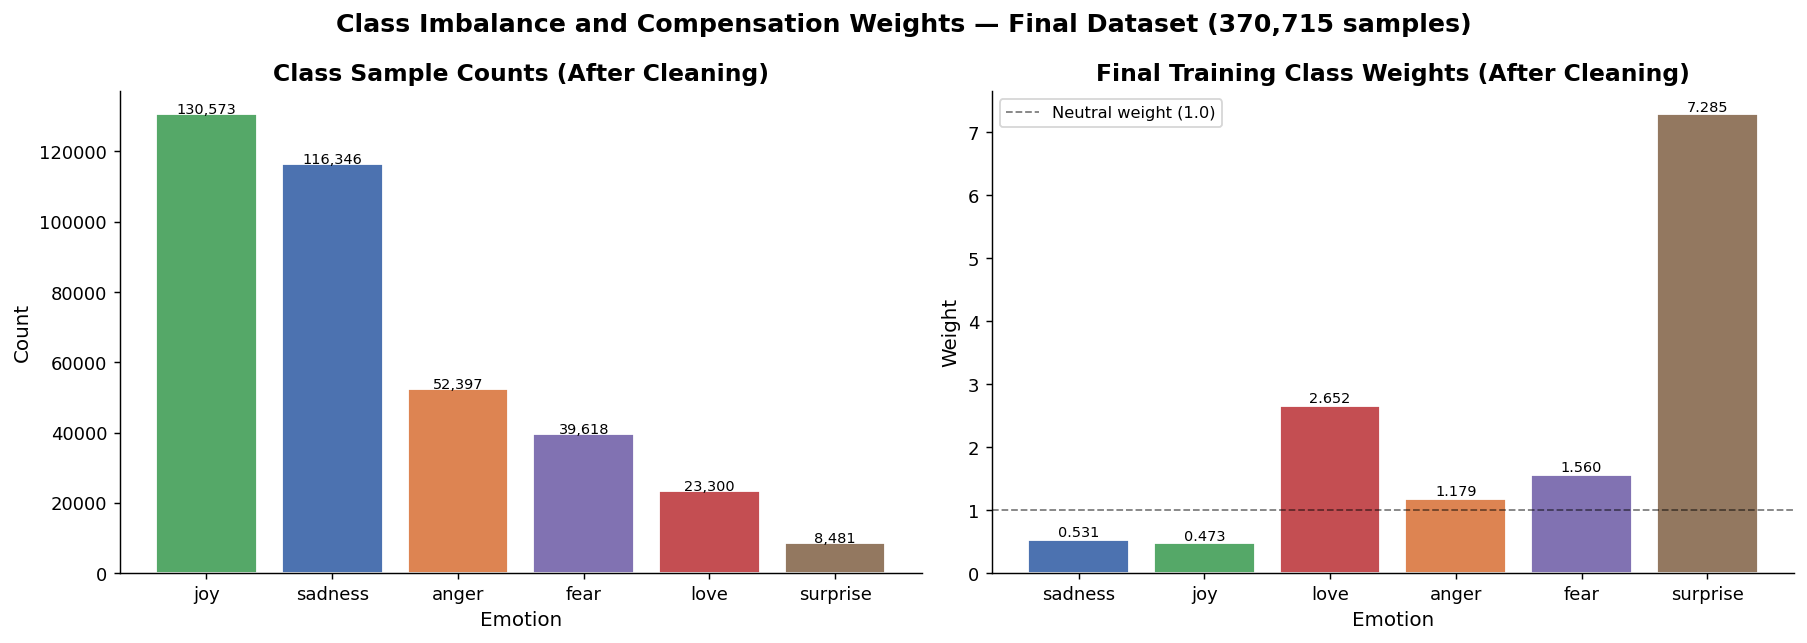

Saved: eda2_06_class_weights.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class counts
colors = [EMOTION_META[NAME_TO_LABEL[e]]['color'] for e in clean3_dist.index]
axes[0].bar(clean3_dist.index, clean3_dist.values, color = colors, edgecolor = 'white')
axes[0].set_title('Class Sample Counts (After Cleaning)', fontweight = 'bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for i, (emotion, count) in enumerate(clean3_dist.items()):
    axes[0].text(i, count + 200, f'{count:,}', ha = 'center', fontsize = 8)

# Class weights
weight_colors = [EMOTION_META[i]['color'] for i in sorted(class_weights.keys())]
weight_labels = [LABEL_TO_NAME[i] for i in sorted(class_weights.keys())]
weight_values = [class_weights[i] for i in sorted(class_weights.keys())]

axes[1].bar(weight_labels, weight_values, color=weight_colors, edgecolor='white')
axes[1].axhline(1.0, color = 'black', linestyle = '--', linewidth = 1, alpha = 0.5, label = 'Neutral weight (1.0)')
axes[1].set_title('Final Training Class Weights (After Cleaning)', fontweight = 'bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Weight')
axes[1].legend(fontsize = 9)
for i, (label, weight) in enumerate(zip(weight_labels, weight_values)):
    axes[1].text(i, weight + 0.05, f'{weight:.3f}', ha='center', fontsize=8)

plt.suptitle('Class Imbalance and Compensation Weights — Final Dataset (370,715 samples)', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('eda2_06_class_weights.png', bbox_inches='tight')
plt.show()
print("Saved: eda2_06_class_weights.png")

## 10. Question 6 (Pipeline Integration Analysis)

Understanding how the emotion label flows into the downstream LLM prompt.

This is why the emotion classifier exists not just to classify but to condition  

the empathy and tone of every chatbot response.

In [36]:
# Demonstrate how emotion feeds into the LLM system prompt in Module 4
# This is the exact structure the RAG module will receive

def build_emotion_context(emotion: str, confidence: float) -> dict:
    label      = NAME_TO_LABEL[emotion]
    meta       = EMOTION_META[label]
    risk_flag  = emotion in ['sadness', 'fear'] and confidence > 0.80

    return {
        'emotion'          : emotion,
        'confidence'       : confidence,
        'mh_significance'  : meta['mh_significance'],
        'response_tone'    : meta['response_tone'],
        'risk_flag'        : risk_flag,
        'llm_instruction'  : (
            f"The user appears to be experiencing {emotion}. "
            f"{meta['response_tone']}. "
            + ("This is a high-risk emotional state — prioritize safety and validation above all." if risk_flag else "")
        )
    }

print("Emotion --> LLM instruction mapping (Module 4 integration):\n")
test_cases = [
    ('sadness',  0.94),
    ('fear',     0.87),
    ('anger',    0.76),
    ('joy',      0.91),
    ('love',     0.83),
    ('surprise', 0.65),
]
for emotion, conf in test_cases:
    ctx = build_emotion_context(emotion, conf)
    print(f"  Emotion    : {ctx['emotion']} (confidence: {ctx['confidence']})")
    print(f"  Risk flag  : {ctx['risk_flag']}")
    print(f"  Instruction: {ctx['llm_instruction']}")
    print()

Emotion --> LLM instruction mapping (Module 4 integration):

  Emotion    : sadness (confidence: 0.94)
  Risk flag  : True
  Instruction: The user appears to be experiencing sadness. Warm, validating, gentle — avoid minimizing. This is a high-risk emotional state — prioritize safety and validation above all.

  Emotion    : fear (confidence: 0.87)
  Risk flag  : True
  Instruction: The user appears to be experiencing fear. Reassuring, grounding, structured. This is a high-risk emotional state — prioritize safety and validation above all.

  Emotion    : anger (confidence: 0.76)
  Risk flag  : False
  Instruction: The user appears to be experiencing anger. Calm, empathetic, non-confrontational. 

  Emotion    : joy (confidence: 0.91)
  Risk flag  : False
  Instruction: The user appears to be experiencing joy. Encouraging, celebratory, engaging. 

  Emotion    : love (confidence: 0.83)
  Risk flag  : False
  Instruction: The user appears to be experiencing love. Warm, affirming, relation

In [37]:
# Risk flag distribution — how often would we elevate care level in production?
high_risk_emotions = ['sadness', 'fear']
high_risk_count    = full_df_clean3[full_df_clean3['emotion'].isin(high_risk_emotions)].shape[0]
high_risk_pct      = high_risk_count / len(full_df_clean3) * 100

print(f"High-risk emotion distribution in dataset:")
print(f"  sadness + fear samples : {high_risk_count:,} ({high_risk_pct:.1f}% of dataset)")
print(f"  Other emotions         : {len(full_df_clean3) - high_risk_count:,} ({100 - high_risk_pct:.1f}% of dataset)")
print()
print("  In a mental health chatbot context this means roughly")
print(f"  {high_risk_pct:.0f}% of user messages will trigger elevated empathy mode.")
print("  The classifier must perform best on exactly these two classes.")

High-risk emotion distribution in dataset:
  sadness + fear samples : 155,964 (42.1% of dataset)
  Other emotions         : 214,751 (57.9% of dataset)

  In a mental health chatbot context this means roughly
  42% of user messages will trigger elevated empathy mode.
  The classifier must perform best on exactly these two classes.


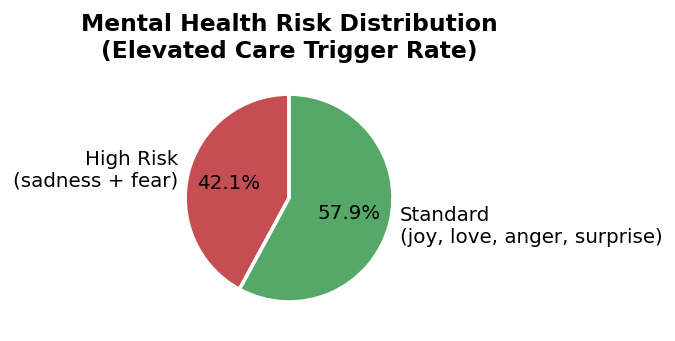

Saved: eda2_07_risk_distribution.png


In [38]:
fig, ax = plt.subplots(figsize=(5, 5))

risk_data = {
    'High Risk\n(sadness + fear)'            : high_risk_count,
    'Standard\n(joy, love, anger, surprise)' : len(full_df_clean3) - high_risk_count
}
risk_colors = ['#C44E52', '#55A868']

wedges, texts, autotexts = ax.pie(
    risk_data.values(),
    labels     = risk_data.keys(),
    colors     = risk_colors,
    autopct    = '%1.1f%%',
    startangle = 90,
    textprops  = {'fontsize': 11},
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title(
    'Mental Health Risk Distribution\n(Elevated Care Trigger Rate)',
    fontsize   = 13,
    fontweight = 'bold'
)

plt.tight_layout()
plt.savefig('eda2_07_risk_distribution.png', bbox_inches = 'tight')
plt.show()
print("Saved: eda2_07_risk_distribution.png")

#### **What 42% Means for our Pipeline**
This is actually a healthy number for a mental health chatbot:

- Not too low if it were 10% the elevated care mode would rarely trigger and you'd question whether the classifier is worth the complexity

- Not too high if it were 70%+ almost every message would trigger high-risk mode which defeats the purpose of having a classifier at all

- 42% means roughly 1 in 2.4 messages triggers elevated empathy that's a meaningful signal that will meaningfully condition LLM responses

## **Part 2: Preprocessing**

This part builds directly on EDA findings.

Every step is justified by a specific observation from Part 1.

**Pipeline:**
1. Environment setup and carry forward cleaned data from EDA
2. Text preprocessing (light cleaning preserving emotional signal)
3. Fix 3 --> within-class duplicate removal on train only
4. Fix 2 --> surprise class augmentation on train only
5. Fix 1 --> recompute and cap class weights from final train distribution
6. Stratified split
7. Final dataset verification before training

## 1. Environment Setup

In [39]:
# Text processing
import re
import random

# NLTK for augmentation
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet',                        quiet = True)
nltk.download('averaged_perceptron_tagger',     quiet = True)
nltk.download('punkt',                          quiet = True)
nltk.download('averaged_perceptron_tagger_eng', quiet = True)

# Data splitting and class weights
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## 2. Text Preprocessing

**Core principle:**

Emotion classification is a semantic task so every step must preserve emotional meaning.

**What we apply:**
- Lowercase — reduces vocabulary without losing emotional signal
- Contraction expansion — makes negation explicit for DistilBERT tokenizer (don't → do not)
- URL removal
- HTML entity removal
- Mention removal (@user)
- Hashtag normalization (#word → word) keep the word but remove the symbol
- Repeated punctuation normalization !!! → `!` (keep intensity signal but remove noise)
- Whitespace normalization

**What we deliberately skip:**
- Stopword removal not, no, never are critical negation words
- Stemming/lemmatization as DistilBERT handles morphology natively
- Full punctuation removal ! and ? carry emotional intensity signal
- Number removal idiomatic expressions like "feel like a million dollars" carry meaning
- Spelling correction intentional repetition like "sooooo sad" carries intensity signal

In [40]:
CONTRACTIONS = {
    "don't"    : "do not",    "doesn't"  : "does not",
    "didn't"   : "did not",   "can't"    : "cannot",
    "won't"    : "will not",  "i'm"      : "i am",
    "i've"     : "i have",    "i'll"     : "i will",
    "i'd"      : "i would",   "it's"     : "it is",
    "that's"   : "that is",   "there's"  : "there is",
    "couldn't" : "could not", "wouldn't" : "would not",
    "isn't"    : "is not",    "aren't"   : "are not",
    "wasn't"   : "was not",   "weren't"  : "were not",
    "hasn't"   : "has not",   "haven't"  : "have not",
    "hadn't"   : "had not",   "shouldn't": "should not",
    "mustn't"  : "must not",  "needn't"  : "need not",
    "daren't"  : "dare not",  "shan't"   : "shall not",
    "mightn't" : "might not", "oughtn't" : "ought not",
}

def preprocess_emotion_text(text: str) -> str:

    text = text.lower()
    # Expand contractions (makes negation explicit for tokenizer)
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML entities
    text = re.sub(r'&\w+;', '', text)
    # Remove @ mentions entirely (username is not emotional signal)
    text = re.sub(r'@\w+', '', text)
    # Remove # symbol but keep the word as hashtag words carry emotion signal
    text = re.sub(r'#(\w+)', r'\1', text)
    # Reduce repeated punctuation to single instance as they preserve intensity signal
    text = re.sub(r'([!?.])\1+', r'\1', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)
    # Strip
    text = text.strip()
    return text

In [41]:
# Verify preprocessing on representative samples before applying to full dataset
test_cases = [
    "I don't feel happy anymore @john #depression",
    "i feel so sad!!!!!!! http://example.com",
    "i can't cope with this &amp; i won't pretend",
    "feeling so ANGRY right now i'm done",
    "i feel like i've been abused by my partner",
    "i'm feeling curious about what happens next #surprised",
]

print("Preprocessing verification:\n")
for text in test_cases:
    cleaned = preprocess_emotion_text(text)
    print(f"  Before : {text}")
    print(f"  After  : {cleaned}")
    print()

Preprocessing verification:

  Before : I don't feel happy anymore @john #depression
  After  : i do not feel happy anymore depression

  Before : i feel so sad!!!!!!! http://example.com
  After  : i feel so sad!

  Before : i can't cope with this &amp; i won't pretend
  After  : i cannot cope with this i will not pretend

  Before : feeling so ANGRY right now i'm done
  After  : feeling so angry right now i am done

  Before : i feel like i've been abused by my partner
  After  : i feel like i have been abused by my partner

  Before : i'm feeling curious about what happens next #surprised
  After  : i am feeling curious about what happens next surprised



In [42]:
# Apply preprocessing to full dataset
full_df_clean3['clean_text'] = full_df_clean3['text'].apply(preprocess_emotion_text)

# Verify no empty strings were created
empty_count = (full_df_clean3['clean_text'].str.strip() == '').sum()
print(f"Empty texts after preprocessing : {empty_count}")

if empty_count > 0:
    full_df_clean3 = full_df_clean3[
        full_df_clean3['clean_text'].str.strip() != ''
    ].reset_index(drop = True)
    print(f"Removed {empty_count} empty texts")

# Verify contraction expansion worked
contraction_check = full_df_clean3['clean_text'].str.contains("don't|can't|won't|i'm").sum()
print(f"Texts still containing contractions : {contraction_check} (expected 0)")
print(f"\nPreprocessing complete : {len(full_df_clean3):,} samples ready")

Empty texts after preprocessing : 0
Texts still containing contractions : 0 (expected 0)

Preprocessing complete : 370,715 samples ready


## 3. Stratified Split

After all EDA cleaning and text preprocessing but before augmentation so that augmented samples only enter the training set.  
Stratification preserves class distribution across all three splits.

In [43]:
train_val_df, test_df = train_test_split(
    full_df_clean3,
    test_size    = 0.10,
    stratify     = full_df_clean3['label'],
    random_state = RANDOM_STATE
)


train_df, val_df = train_test_split(
    train_val_df,
    test_size    = 0.111,
    stratify     = train_val_df['label'],
    random_state = RANDOM_STATE
)

print(f"Split sizes:")
print(f"  Train : {len(train_df):,} ({len(train_df)/len(full_df_clean3)*100:.1f}%)")
print(f"  Val   : {len(val_df):,} ({len(val_df)/len(full_df_clean3)*100:.1f}%)")
print(f"  Test  : {len(test_df):,} ({len(test_df)/len(full_df_clean3)*100:.1f}%)")
print()

# Verify stratification
print(f"  {'Emotion':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print(f"  {'-'*44}")
for label in sorted(LABEL_TO_NAME.keys()):
    emotion  = LABEL_TO_NAME[label]
    tr_pct   = (train_df['label'] == label).sum() / len(train_df) * 100
    va_pct   = (val_df['label']   == label).sum() / len(val_df)   * 100
    te_pct   = (test_df['label']  == label).sum() / len(test_df)  * 100
    print(f"  {emotion:<12} {tr_pct:>9.2f}%  {va_pct:>9.2f}%  {te_pct:>9.2f}%")

Split sizes:
  Train : 296,608 (80.0%)
  Val   : 37,035 (10.0%)
  Test  : 37,072 (10.0%)

  Emotion           Train        Val       Test
  --------------------------------------------
  sadness          31.38%      31.38%      31.38%
  joy              35.22%      35.22%      35.22%
  love              6.29%       6.29%       6.29%
  anger            14.13%      14.14%      14.13%
  fear             10.69%      10.69%      10.69%
  surprise          2.29%       2.29%       2.29%


## 4. Within-Class Duplicate Removal (Train Only)

**EDA finding:**

The dataset came from Twitter and users post near-identical tweets.  
Keeping same-label duplicates causes the model to memorize specific sentences  
rather than learning the underlying emotion pattern a subtle form of overfitting.

**Applied to train only**

val and test must remain untouched to give unbiased evaluation on naturally distributed data including duplicates.

In [44]:
before_dedup = len(train_df)

# Remove exact duplicates within each class
# keep = 'first' retains the first occurrence and removes all subsequent identical texts
train_df_dedup = (
    train_df
    .drop_duplicates(subset = ['clean_text', 'label'], keep = 'first')
    .reset_index(drop = True)
)

removed_dedup  = before_dedup - len(train_df_dedup)

print(f"Within-class duplicate removal (train only):")
print(f"  Before : {before_dedup:,}")
print(f"  Removed: {removed_dedup:,} ({removed_dedup/before_dedup*100:.2f}%)")
print(f"  After  : {len(train_df_dedup):,}")
print()

Within-class duplicate removal (train only):
  Before : 296,608
  Removed: 404 (0.14%)
  After  : 296,204



In [45]:
# Per-class duplicate breakdown
dedup_records = []
for label in sorted(LABEL_TO_NAME.keys()):
    original = (train_df['label']       == label).sum()
    after    = (train_df_dedup['label'] == label).sum()
    removed  = original - after
    dedup_records.append({
        'emotion'  : LABEL_TO_NAME[label],
        'original' : original,
        'after'    : after,
        'removed'  : removed,
        'pct'      : removed / original * 100 if original > 0 else 0
    })


dedup_df = pd.DataFrame(dedup_records).sort_values('removed', ascending = False)
display(
    dedup_df.reset_index(drop = True)
    .style
    .set_caption("Within-class Duplicates Removed from Train Set")
    .format({'original': '{:,}', 'after': '{:,}', 'removed': '{:,}', 'pct': '{:.2f}%'})
    .bar(subset = ['removed'], color = '#DD8452', vmin = 0)
    .set_properties(**{'text-align': 'left'})
)

,emotion,original,after,removed,pct
0,joy,"104,472","104,276",196,0.19%
1,sadness,"93,088","92,976",112,0.12%
2,anger,"41,922","41,877",45,0.11%
3,love,"18,642","18,618",24,0.13%
4,fear,"31,698","31,677",21,0.07%
5,surprise,"6,786","6,780",6,0.09%


## 5.Surprise Class Augmentation (Train Only)

**EDA finding:**

Surprise is only 2.3% of data after dedup it shrinks further.  
A Transformer fine-tuned on fewer than ~10k samples per class risks underfitting that class.

**Method:**

random word deletion or random word swap

**Target:**

Bring surprise to 20,000 samples in the training set.

In [46]:
def random_deletion(text: str, p: float = 0.20) -> str:
    words     = text.split()
    if len(words) <= 6:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if len(new_words) >= 3 else text


def augment_text(text: str) -> str:
    return random_deletion(text, p = 0.15)

In [47]:
SURPRISE_LABEL = NAME_TO_LABEL['surprise']
AUGMENT_TARGET = 20_000

surprise_train = train_df_dedup[train_df_dedup['label'] == SURPRISE_LABEL]
surprise_texts = surprise_train['clean_text'].tolist()
current_count  = len(surprise_texts)
needed         = AUGMENT_TARGET - current_count

print(f"Surprise samples before augmentation : {current_count:,}")
print(f"Target count                          : {AUGMENT_TARGET:,}")
print(f"Samples to generate                   : {needed:,}")
print()

print("Augmentation quality check (5 examples):\n")
for orig in random.sample(surprise_texts, 5):
    aug = augment_text(orig)
    print(f"  Original  : {orig}")
    print(f"  Augmented : {aug}")
    print()

Surprise samples before augmentation : 6,780
Target count                          : 20,000
Samples to generate                   : 13,220

Augmentation quality check (5 examples):

  Original  : i find i am always more than a little surprised that i feel that way surprised and proud
  Augmented : i find i am always more than a surprised that i feel that way surprised and proud

  Original  : i looked back through all my past experiences at work there was no way i could feel any less impressed or humbled by the knowledge and skills that i had learned as part of the entire process of my career development
  Augmented : i looked back all past at work there was no way could feel any impressed humbled by the knowledge and skills that i learned as part of entire process of my career

  Original  : i feel less impressed with the not so great stuff that happens in a typical day because i remember the long list of good that ive recorded
  Augmented : i feel impressed with the not great stuff t

In [48]:
# original train samples overlapping with val/test so remove overlapping texts from train_df_dedup before augmentation

val_texts_set  = set(val_df['clean_text'].tolist())
test_texts_set = set(test_df['clean_text'].tolist())

train_leak_mask   = train_df_dedup['clean_text'].isin(val_texts_set | test_texts_set)
train_leak_count  = train_leak_mask.sum()

train_df_dedup    = train_df_dedup[~train_leak_mask].reset_index(drop=True)

print(f"Leaking train samples removed : {train_leak_count:,}")
print(f"Train size after fix          : {len(train_df_dedup):,}")

Leaking train samples removed : 184
Train size after fix          : 296,020


In [49]:
# generate full augmented dataset
augmented_texts  = []
augmented_labels = []
attempts         = 0
max_attempts     = needed * 3

while len(augmented_texts) < needed and attempts < max_attempts:
    original  = random.choice(surprise_texts)
    augmented = augment_text(original)
    if augmented != original:
        augmented_texts.append(augmented)
        augmented_labels.append(SURPRISE_LABEL)
    attempts += 1

aug_df = pd.DataFrame({
    'text'       : augmented_texts,
    'clean_text' : augmented_texts,
    'label'      : augmented_labels,
    'emotion'    : 'surprise'
})

print(f"Augmented samples generated : {len(aug_df):,}")
print(f"Generation attempts         : {attempts:,}")
print(f"Success rate                : {len(aug_df)/attempts*100:.1f}%")

Augmented samples generated : 13,220
Generation attempts         : 15,417
Success rate                : 85.7%


In [50]:
# Remove augmented samples that leak into val or test
val_texts_set  = set(val_df['clean_text'].tolist())
test_texts_set = set(test_df['clean_text'].tolist())

aug_df_clean = aug_df[
    ~aug_df['clean_text'].isin(val_texts_set) &
    ~aug_df['clean_text'].isin(test_texts_set)
].reset_index(drop=True)

leaked = len(aug_df) - len(aug_df_clean)
print(f"Augmented samples generated  : {len(aug_df):,}")
print(f"Leaked into val/test removed : {leaked:,}")
print(f"Clean augmented samples      : {len(aug_df_clean):,}")

# Merge clean augmented samples into training set
train_df_final = pd.concat(
    [train_df_dedup, aug_df_clean[['text', 'clean_text', 'label', 'emotion']]],
    ignore_index = True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTraining set after augmentation:")
print(f"  Before : {len(train_df_dedup):,}")
print(f"  After  : {len(train_df_final):,}")
print(f"  Added  : {len(aug_df_clean):,} surprise samples")

surprise_final = (train_df_final['label'] == SURPRISE_LABEL).sum()
print(f"\n  Surprise class count : {surprise_final:,}")

Augmented samples generated  : 13,220
Leaked into val/test removed : 1
Clean augmented samples      : 13,219

Training set after augmentation:
  Before : 296,020
  After  : 309,239
  Added  : 13,219 surprise samples

  Surprise class count : 19,998


## 6. Recompute and Cap Class Weights

**EDA finding:**

Raw balanced weights gave surprise a weight of 7.28 (15x higher)  
than joy.
This causes training instability extreme gradients on surprise samples  
destabilize the loss for dominant classes.

**Solution:**

Recompute weights from the final training distribution after dedup  
and augmentation then cap at 4.0 to prevent any single class from dominating gradients.

In [51]:
MAX_WEIGHT = 4.0

raw_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(sorted(train_df_final['label'].unique())),
    y            = train_df_final['label'].values
)

raw_weights    = {i: w for i, w in enumerate(raw_weights_array)}
class_weights  = {k: min(v, MAX_WEIGHT) for k, v in raw_weights.items()}

print(f"Class weights after all cleaning and augmentation (cap = {MAX_WEIGHT}):\n")
print(f"  {'emotion':<12} {'count':>10}  {'raw weight':>12}  {'final weight':>14}  {'status'}")
print(f"  {'-'*65}")


for label in sorted(class_weights.keys()):
    emotion  = LABEL_TO_NAME[label]
    count    = (train_df_final['label'] == label).sum()
    raw_w    = raw_weights[label]
    final_w  = class_weights[label]
    status   = 'capped' if raw_w != final_w else 'unchanged'
    print(f"  {emotion:<12} {count:>10,}  {raw_w:>12.4f}  {final_w:>14.4f}  {status}")

Class weights after all cleaning and augmentation (cap = 4.0):

  emotion           count    raw weight    final weight  status
  -----------------------------------------------------------------
  sadness          92,907        0.5547          0.5547  unchanged
  joy             104,208        0.4946          0.4946  unchanged
  love             18,604        2.7704          2.7704  unchanged
  anger            41,855        1.2314          1.2314  unchanged
  fear             31,667        1.6276          1.6276  unchanged
  surprise         19,998        2.5772          2.5772  unchanged


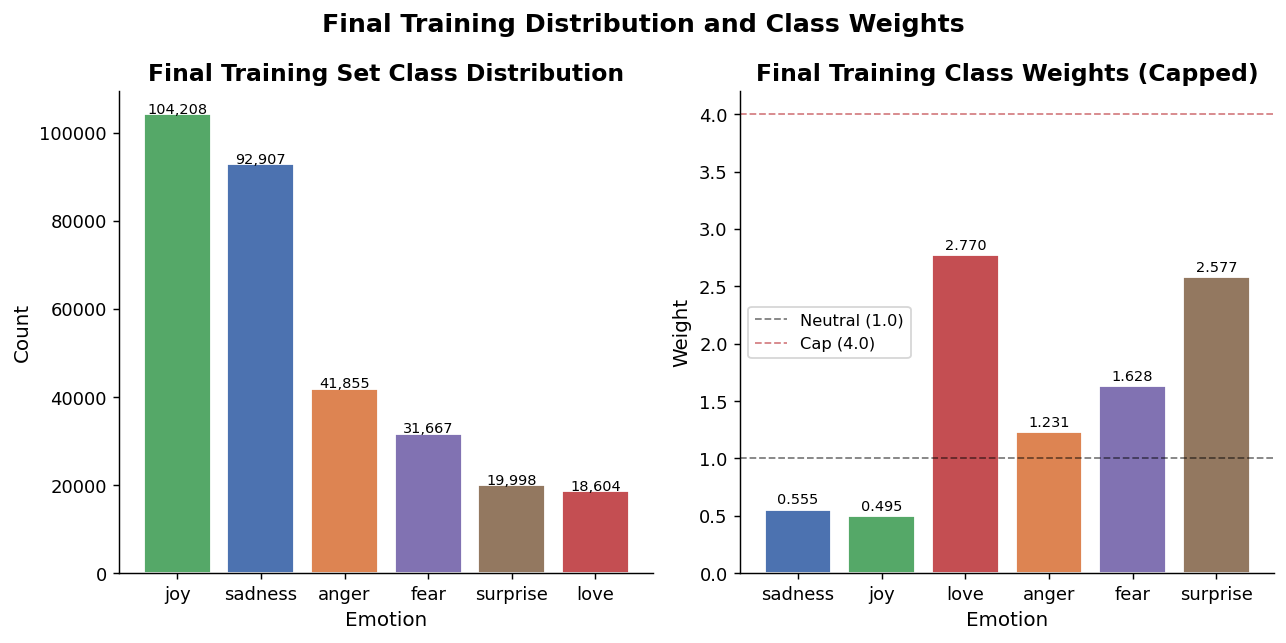

Saved: prep2_01_final_distribution.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))

# Final class distribution in training set
final_dist   = train_df_final['emotion'].value_counts()
dist_colors  = [EMOTION_META[NAME_TO_LABEL[e]]['color'] for e in final_dist.index]

axes[0].bar(final_dist.index, final_dist.values, color = dist_colors, edgecolor = 'white')
axes[0].set_title('Final Training Set Class Distribution', fontweight = 'bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for i, (emotion, count) in enumerate(final_dist.items()):
    axes[0].text(i, count + 200, f'{count:,}', ha = 'center', fontsize = 8)

# Final class weights
weight_labels = [LABEL_TO_NAME[i] for i in sorted(class_weights.keys())]
weight_values = [class_weights[i]  for i in sorted(class_weights.keys())]
weight_colors = [EMOTION_META[i]['color'] for i in sorted(class_weights.keys())]

axes[1].bar(weight_labels, weight_values, color = weight_colors, edgecolor = 'white')
axes[1].axhline(1.0, color = 'black', linestyle = '--', linewidth = 1, alpha = 0.5, label = 'Neutral (1.0)')
axes[1].axhline(MAX_WEIGHT, color = '#C44E52', linestyle = '--', linewidth = 1,
                alpha = 0.7, label = f'Cap ({MAX_WEIGHT})')
axes[1].set_title('Final Training Class Weights (Capped)', fontweight = 'bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Weight')
axes[1].legend(fontsize = 9)
for i, (label, weight) in enumerate(zip(weight_labels, weight_values)):
    axes[1].text(i, weight + 0.05, f'{weight:.3f}', ha = 'center', fontsize = 8)

plt.suptitle('Final Training Distribution and Class Weights', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('prep2_01_final_distribution.png', bbox_inches = 'tight')
plt.show()
print("Saved: prep2_01_final_distribution.png")

## 7. Final Dataset Verification

Complete sanity check before handing data to the model training section

In [53]:
# Remove val/test overlap keep in val but remove from test
val_text_set   = set(val_df['clean_text'].tolist())
overlap_mask   = test_df['clean_text'].isin(val_text_set)
overlap_count  = overlap_mask.sum()

test_df = test_df[~overlap_mask].reset_index(drop=True)

print(f"Val ∩ Test overlap removed from test : {overlap_count:,}")
print(f"Test size after fix                  : {len(test_df):,}")

Val ∩ Test overlap removed from test : 20
Test size after fix                  : 37,052


In [54]:
train_texts = set(train_df_final['clean_text'])
val_texts   = set(val_df['clean_text'])
test_texts  = set(test_df['clean_text'])

train_val_overlap  = len(train_texts & val_texts)
train_test_overlap = len(train_texts & test_texts)
val_test_overlap   = len(val_texts   & test_texts)

print("Data leakage check:")
print(f"  Train ∩ Val  overlap : {train_val_overlap}  (expected 0)")
print(f"  Train ∩ Test overlap : {train_test_overlap}  (expected 0)")
print(f"  Val   ∩ Test overlap : {val_test_overlap}  (expected 0)")

assert train_val_overlap  == 0, "Train/Val leakage detected"
assert train_test_overlap == 0, "Train/Test leakage detected"
assert val_test_overlap   == 0, "Val/Test leakage detected"
print("\nAll checks passed (no leakage)")

Data leakage check:
  Train ∩ Val  overlap : 0  (expected 0)
  Train ∩ Test overlap : 0  (expected 0)
  Val   ∩ Test overlap : 0  (expected 0)

All checks passed (no leakage)


In [55]:
# Verify no empty texts in any split
for split_name, df in [('Train', train_df_final), ('Val', val_df), ('Test', test_df)]:
    empty = (df['clean_text'].str.strip() == '').sum()
    print(f"  {split_name} empty texts : {empty}  (expected 0)")

  Train empty texts : 0  (expected 0)
  Val empty texts : 0  (expected 0)
  Test empty texts : 0  (expected 0)


In [56]:
# Spot check
print("Spot check (3 samples per class after all preprocessing):\n")
for label in sorted(LABEL_TO_NAME.keys()):
    emotion = LABEL_TO_NAME[label]
    samples = (
        train_df_final[train_df_final['label'] == label]['clean_text']
        .sample(3, random_state = RANDOM_STATE)
        .tolist()
    )
    print(f"  [{label}] {emotion.upper()}")
    for i, s in enumerate(samples, 1):
        print(f"    {i}. {s[:110]}")
    print()

print("Spot check (3 samples per class after all preprocessing):\n")
for label in sorted(LABEL_TO_NAME.keys()):
    emotion = LABEL_TO_NAME[label]
    samples = (
        train_df_final[train_df_final['label'] == label]['clean_text']
        .sample(3, random_state = RANDOM_STATE)
        .tolist()
    )
    print(f"  [{label}] {emotion.upper()}")
    for i, s in enumerate(samples, 1):
        print(f"    {i}. {s[:110]}")
    print()

Spot check (3 samples per class after all preprocessing):

  [0] SADNESS
    1. i feel i dont think im lame for this
    2. i spent a few hours feeling pretty crappy about it
    3. im just still feeling rotten about this morning

  [1] JOY
    1. i agree with plato in that every child has a special gift and every child is individual and unique but plato l
    2. i feel loads of pressure to be all productive and sort things and arrange items etc
    3. i am feeling jubilant for those mainly young people for the power of those people

  [2] LOVE
    1. i feel even more delicate than i did before
    2. i often feel nostalgic about the touch of the black and white piano keys and the vibration that echoes in the 
    3. i read about him and learn about him in his interviews the more i feel like i could never deserve someone so k

  [3] ANGER
    1. i feel like some kind of anomaly being bothered by this kind of thing
    2. id be smaller and some part of them would feel jealous or id be l

## **Part 3: Training**

This part fine-tunes distilbert-base-multilingual-cased on the preprocessed dataset produced in Part 2

**Pipeline:**
1. Environment setup and handoff verification from preprocessing
2. Tokenizer and dataset construction
3. Model architecture with weighted loss
4. Training loop with early stopping
5. Evaluation (weighted F1, per-class F1, confusion matrix)
6. Error analysis (critical failure mode inspection)
7. Save model, tokenizer, and all artifacts needed by downstream modules

## 1. Environment Setup

In [57]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

from pathlib import Path

MODEL_NAME = 'distilbert-base-multilingual-cased'
OUTPUT_DIR = Path('emotion_classifier_model')
OUTPUT_DIR.mkdir(exist_ok = True)

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device        : {DEVICE}")
print(f"PyTorch       : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Output dir    : {OUTPUT_DIR}")

Device        : cuda
PyTorch       : 2.8.0+cu128
GPU           : NVIDIA A100-SXM4-40GB
VRAM          : 42.4 GB
Output dir    : emotion_classifier_model


## 2. Tokenizer and Dataset Construction

**Tokenizer choice:** distilbert-base-multilingual-cased

Cased model is preferred because emotion is case-sensitive   
"I HATE this" carries different intensity than "i hate this"

**max_length = 128**

validated in EDA: 99th percentile of token counts is below 128.  
Padding to max_length ensures uniform batch tensors for the DataLoader.

In [58]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer     : {MODEL_NAME}")
print(f"Vocab size    : {tokenizer.vocab_size:,}")
print(f"Max length    : 128 (validated in EDA)")
print()

# Spot-check tokenization on one real sample
sample_text   = train_df_final['clean_text'].iloc[0]
sample_tokens = tokenizer(sample_text, max_length = 128, truncation = True)
print(f"Sample text   : {sample_text[:80]}")
print(f"Token count   : {len(sample_tokens['input_ids'])}")
print(f"Decoded       : {tokenizer.decode(sample_tokens['input_ids'])[:80]}")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Tokenizer     : distilbert-base-multilingual-cased
Vocab size    : 119,547
Max length    : 128 (validated in EDA)

Sample text   : i feel like i m damaged goods and that he deserves better than this
Token count   : 18
Decoded       : [CLS] i feel like i m damaged goods and that he deserves better than this [SEP]


In [59]:
class EmotionDataset(Dataset):
    """
    PyTorch Dataset for emotion classification.
    Tokenizes on construction so the DataLoader serves pre-tokenized tensors
    no repeated tokenization during training.
    """

    def __init__(self, texts, labels, tokenizer, max_length = 128):
        self.labels    = torch.tensor(labels, dtype = torch.long)
        self.encodings = tokenizer(
            texts,
            max_length      = max_length,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.encodings['input_ids'][idx],
            'attention_mask' : self.encodings['attention_mask'][idx],
            'labels'         : self.labels[idx]
        }


print("Building datasets (tokenizing all splits)")

train_dataset = EmotionDataset(
    train_df_final['clean_text'].tolist(),
    train_df_final['label'].tolist(),
    tokenizer
)


val_dataset = EmotionDataset(
    val_df['clean_text'].tolist(),
    val_df['label'].tolist(),
    tokenizer
)

test_dataset = EmotionDataset(
    test_df['clean_text'].tolist(),
    test_df['label'].tolist(),
    tokenizer
)


Building datasets (tokenizing all splits)


In [60]:
print(f"  Train dataset : {len(train_dataset):,} samples")
print(f"  Val dataset   : {len(val_dataset):,} samples")
print(f"  Test dataset  : {len(test_dataset):,} samples")
print()

# Verify one batch shape
batch = train_dataset[0]
print(f"  Batch keys    : {list(batch.keys())}")
print(f"  input_ids     : {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  label         : {batch['labels'].item()} ({LABEL_TO_NAME[batch['labels'].item()]})")

  Train dataset : 309,239 samples
  Val dataset   : 37,035 samples
  Test dataset  : 37,052 samples

  Batch keys    : ['input_ids', 'attention_mask', 'labels']
  input_ids     : torch.Size([128])
  attention_mask: torch.Size([128])
  label         : 0 (sadness)


In [61]:
# DataLoaders
# Batch size 32 is safe for DistilBERT + max_length = 128 on a 16GB GPU (Reduce to 16 if OOM errors occur)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True if torch.cuda.is_available() else False
)


val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True if torch.cuda.is_available() else False
)


test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True if torch.cuda.is_available() else False
)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Train batches       : {len(train_loader):,}")
print(f"Val batches         : {len(val_loader):,}")
print(f"Test batches        : {len(test_loader):,}")

Batch size          : 128
Train batches       : 2,416
Val batches         : 290
Test batches        : 290


## 3. Model Architecture with Weighted Loss

**Base model:** distilbert-base-multilingual-cased  
**Head:** Linear classification layer (768 → 6 classes) added by HuggingFace automatically.

**Weighted CrossEntropyLoss:**  
Class weights from preprocessing (capped at 4.0) are passed directly  
into the loss function and the model penalizes errors on minority classes  
(love, surprise) more heavily than on dominant classes (joy, sadness)

In [62]:
NUM_LABELS     = len(EMOTION_META)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_LABELS
)
model = model.to(DEVICE)

# Weighted loss — carries class_weights from preprocessing
weights_tensor = torch.tensor(
    [class_weights[i] for i in range(NUM_LABELS)],
    dtype = torch.float
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight = weights_tensor)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [63]:
print(f"Model             : {MODEL_NAME}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Device            : {DEVICE}")
print()
print(f"Loss function     : CrossEntropyLoss (weighted)")
print(f"Class weights     : {[round(class_weights[i], 4) for i in range(NUM_LABELS)]}")

Model             : distilbert-base-multilingual-cased
Total parameters  : 135,329,286
Trainable params  : 135,329,286
Device            : cuda

Loss function     : CrossEntropyLoss (weighted)
Class weights     : [0.5547, 0.4946, 2.7704, 1.2314, 1.6276, 2.5772]


## 4. Training Configuration

**Optimizer:** AdamW with weight decay (standard for transformer fine-tuning)  
**Learning rate:** 2e-5  well-established sweet spot for DistilBERT fine-tuning  
**Warmup steps:** 10% of total steps to prevent large gradient updates in early epochs
**Early stopping:** patience = 2 on val weighted F1 to stop before overfitting on SURPRISE augmented samples

In [64]:
# Hyperparameters
EPOCHS          = 5
LEARNING_RATE   = 2e-5
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.10
EARLY_STOP_PAT  = 2       # patience epochs on val weighted F1
total_steps     = len(train_loader) * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)


In [65]:
print(f"Epochs            : {EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"Total steps       : {total_steps:,}")
print(f"Warmup steps      : {warmup_steps:,} ({WARMUP_RATIO*100:.0f}% of total)")
print(f"Early stop pat.   : {EARLY_STOP_PAT} epochs")

Epochs            : 5
Learning rate     : 2e-05
Weight decay      : 0.01
Total steps       : 12,080
Warmup steps      : 1,208 (10% of total)
Early stop pat.   : 2 epochs


## 5. Training Loop

Tracks weighted F1 on the validation set after each epoch.  
Best model checkpoint is saved whenever val weighted F1 improves.  
Training stops early if val F1 does not improve for EARLY_STOP_PAT consecutive epochs.

In [66]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss   = 0.0
    all_preds    = []
    all_labels   = []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids = input_ids, attention_mask = attention_mask)
        loss    = criterion(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim = -1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss     = total_loss / len(loader)
    weighted_f1  = f1_score(all_labels, all_preds, average = 'weighted', zero_division = 0)
    return avg_loss, weighted_f1

print("Training function defined")


Training function defined


In [67]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss   = 0.0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids = input_ids, attention_mask = attention_mask)
            loss    = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim = -1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss     = total_loss / len(loader)
    weighted_f1  = f1_score(all_labels, all_preds, average = 'weighted', zero_division = 0)
    return avg_loss, weighted_f1, all_preds, all_labels


print("Evaluation function defined")

Evaluation function defined


In [68]:
# Training Loop
history          = []
best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0
BEST_MODEL_PATH  = OUTPUT_DIR / 'best_model.pt'

print(f"{'Epoch':<7} {'Train Loss':<13} {'Train F1':<12} {'Val Loss':<12} {'Val F1':<10} {'Status'}")
print("-" * 68)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1             = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss,   val_f1, _, _         = eval_epoch(model, val_loader, criterion, DEVICE)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1      = val_f1
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        status = "saved"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{EARLY_STOP_PAT}"

    history.append({
        'epoch'      : epoch,
        'train_loss' : train_loss,
        'train_f1'   : train_f1,
        'val_loss'   : val_loss,
        'val_f1'     : val_f1
    })

    print(f"{epoch:<7} {train_loss:<13.4f} {train_f1:<12.4f} {val_loss:<12.4f} {val_f1:<10.4f} {status}")

    if patience_counter >= EARLY_STOP_PAT:
        print(f"\nEarly stopping at epoch {epoch} — best val F1 was {best_val_f1:.4f} at epoch {best_epoch}")
        break

print(f"\nBest model : epoch {best_epoch}  val weighted F1 = {best_val_f1:.4f}")
print(f"Saved to   : {BEST_MODEL_PATH}")

Epoch   Train Loss    Train F1     Val Loss     Val F1     Status
--------------------------------------------------------------------
1       0.3782        0.8603       0.0275       0.9917     saved
2       0.0367        0.9905       0.0207       0.9933     saved
3       0.0238        0.9936       0.0173       0.9939     saved
4       0.0155        0.9957       0.0192       0.9947     saved
5       0.0104        0.9971       0.0228       0.9946     patience 1/2

Best model : epoch 4  val weighted F1 = 0.9947
Saved to   : emotion_classifier_model/best_model.pt


## 6. Training Curves

Visualize loss and weighted F1 across epochs.  
Diverging train/val curves signal overfitting.  
Flat val F1 with rising train F1 signals memorization of augmented SURPRISE samples.

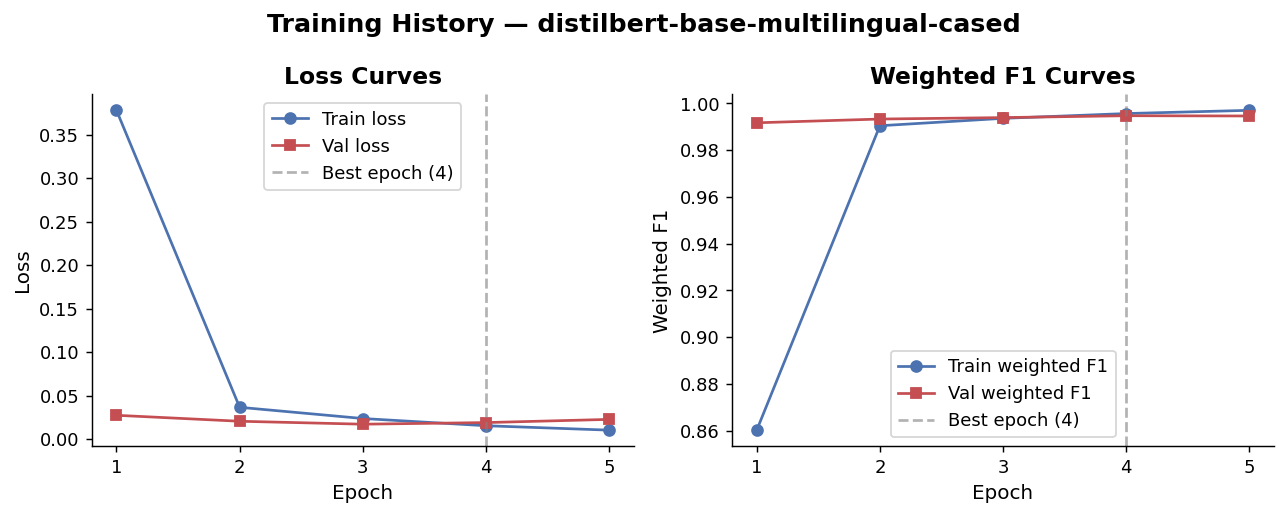

Saved: train3_01_training_curves.png


In [69]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

# Loss curves
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker = 'o', label = 'Train loss', color = '#4C72B0')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   marker = 's', label = 'Val loss',   color = '#C44E52')
axes[0].axvline(best_epoch, color = 'grey', linestyle = '--', alpha = 0.6, label = f'Best epoch ({best_epoch})')
axes[0].set_title('Loss Curves', fontweight = 'bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer = True))

# F1 curves
axes[1].plot(history_df['epoch'], history_df['train_f1'], marker = 'o', label = 'Train weighted F1', color = '#4C72B0')
axes[1].plot(history_df['epoch'], history_df['val_f1'],   marker = 's', label = 'Val weighted F1',   color = '#C44E52')
axes[1].axvline(best_epoch, color = 'grey', linestyle = '--', alpha = 0.6, label = f'Best epoch ({best_epoch})')
axes[1].set_title('Weighted F1 Curves', fontweight = 'bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer = True))

plt.suptitle('Training History — distilbert-base-multilingual-cased', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train3_01_training_curves.png', bbox_inches = 'tight')
plt.show()
print("Saved: train3_01_training_curves.png")

## 7. Evaluation on Test Set

Load the best checkpoint and evaluate on the held-out test set.

**Primary metric:** Weighted F1   
**Secondary metrics:** Per-class F1, precision, recall to diagnose SURPRISE and LOVE

**Confusion matrix:** Reveals the critical sadness→joy failure mode identified in EDA.

In [70]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location = DEVICE))
model.eval()
print(f"Loaded best checkpoint from epoch {best_epoch}")
print()

# Run inference on test set
_, _, test_preds, test_labels = eval_epoch(model, test_loader, criterion, DEVICE)

#  Overall metrics
weighted_f1 = f1_score(test_labels, test_preds, average = 'weighted', zero_division = 0)
macro_f1    = f1_score(test_labels, test_preds, average = 'macro',    zero_division = 0)
accuracy    = accuracy_score(test_labels, test_preds)

print(f"Test results (n = {len(test_labels):,}):")
print(f"  Weighted F1   : {weighted_f1:.4f}")
print(f"  Macro F1      : {macro_f1:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print()

# Per-class report
target_names = [LABEL_TO_NAME[i] for i in range(NUM_LABELS)]
report       = classification_report(
    test_labels, test_preds,
    target_names  = target_names,
    zero_division = 0
)
print("Per-class classification report:")
print(report)

Loaded best checkpoint from epoch 4

Test results (n = 37,052):
  Weighted F1   : 0.9948
  Macro F1      : 0.9915
  Accuracy      : 0.9948

Per-class classification report:
              precision    recall  f1-score   support

     sadness       1.00      1.00      1.00     11629
         joy       1.00      1.00      1.00     13046
        love       1.00      1.00      1.00      2329
       anger       0.99      0.99      0.99      5240
        fear       0.99      0.98      0.99      3960
    surprise       0.96      1.00      0.98       848

    accuracy                           0.99     37052
   macro avg       0.99      0.99      0.99     37052
weighted avg       0.99      0.99      0.99     37052



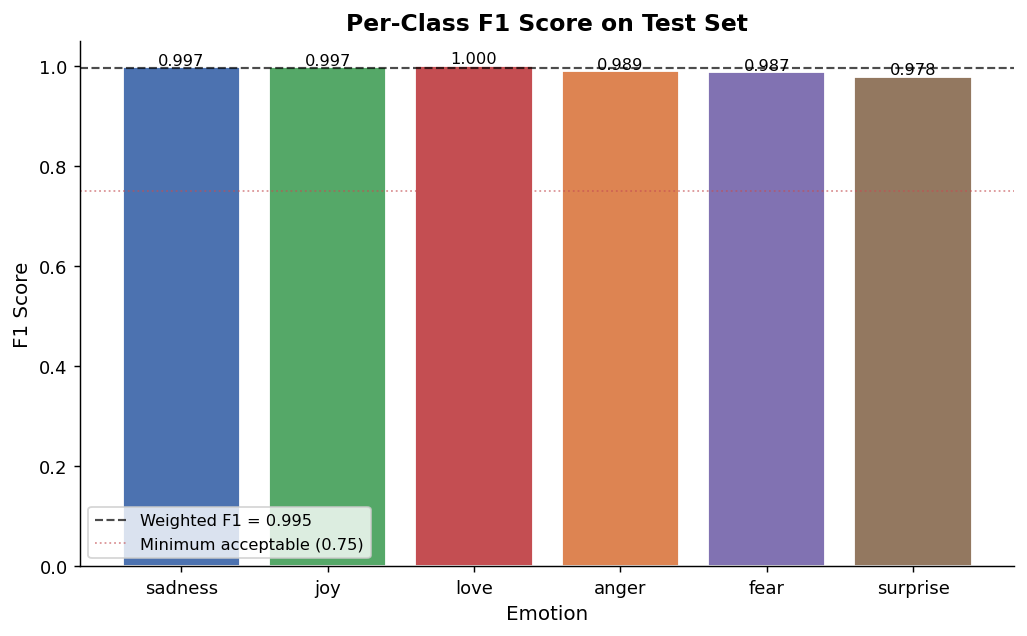

Saved: train3_02_per_class_f1.png


In [71]:
# Per-class F1 bar chart
per_class_f1 = f1_score(test_labels, test_preds, average = None, zero_division = 0)
fig, ax = plt.subplots(figsize = (8, 5))
colors = [LABEL_TO_COLOR[i] for i in range(NUM_LABELS)]
bars   = ax.bar(target_names, per_class_f1, color = colors, edgecolor = 'white')

ax.axhline(weighted_f1, color = 'black', linestyle = '--', linewidth = 1.2,
           alpha = 0.7, label = f'Weighted F1 = {weighted_f1:.3f}')
ax.axhline(0.75, color = '#C44E52', linestyle = ':', linewidth = 1.0,
           alpha = 0.6, label = 'Minimum acceptable (0.75)')

for bar, f1 in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{f1:.3f}', ha = 'center', fontsize = 9)


ax.set_title('Per-Class F1 Score on Test Set', fontweight = 'bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize = 9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train3_02_per_class_f1.png', bbox_inches = 'tight')
plt.show()
print("Saved: train3_02_per_class_f1.png")

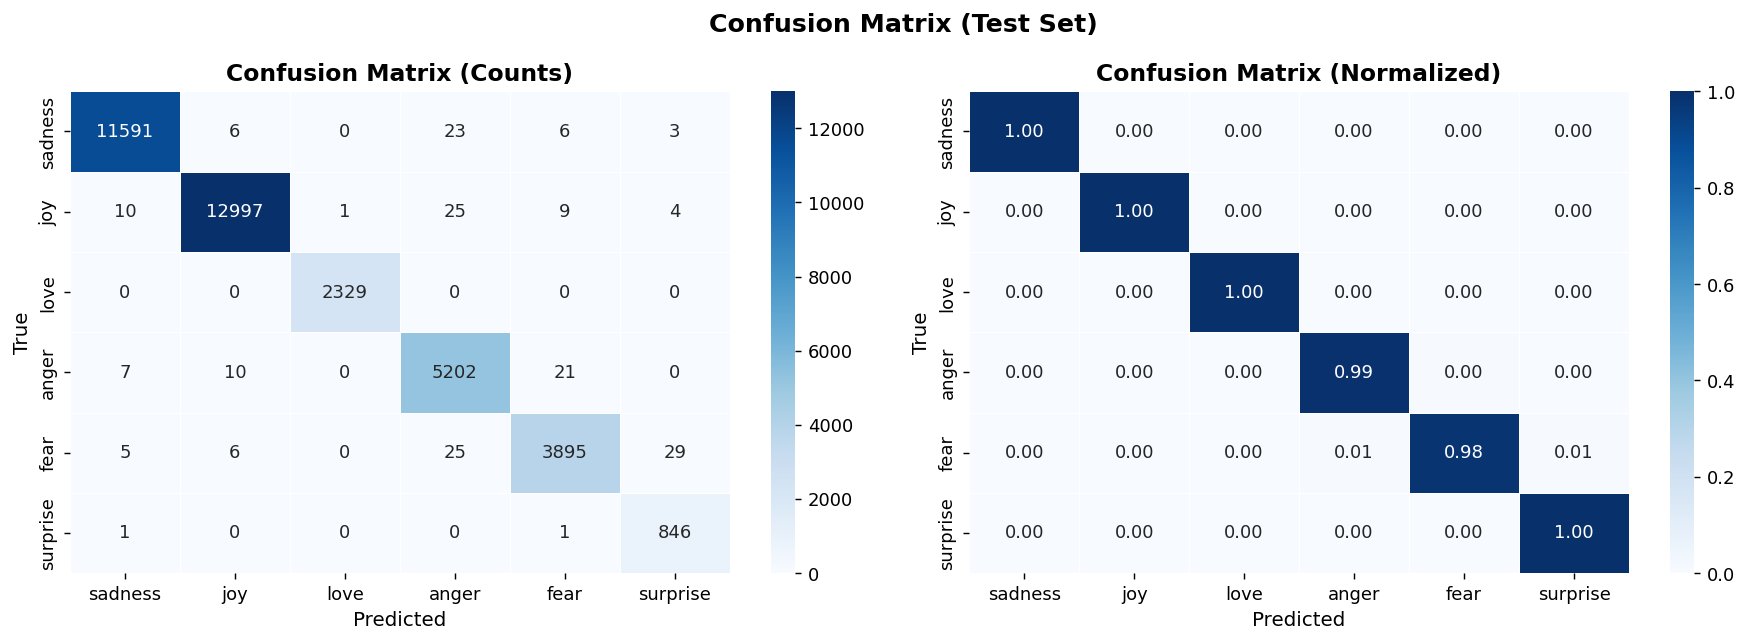

Saved: train3_03_confusion_matrix.png


In [72]:
# Confusion matrix
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis = 1, keepdims = True)  # row-normalized

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Raw counts
sns.heatmap(
    cm, annot = True, fmt = 'd', cmap = 'Blues',
    xticklabels = target_names, yticklabels = target_names,
    ax = axes[0], linewidths = 0.5
)
axes[0].set_title('Confusion Matrix (Counts)', fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')


sns.heatmap(
    cm_norm, annot = True, fmt = '.2f', cmap = 'Blues',
    xticklabels = target_names, yticklabels = target_names,
    ax = axes[1], linewidths = 0.5, vmin = 0, vmax = 1
)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrix (Test Set)', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train3_03_confusion_matrix.png', bbox_inches = 'tight')
plt.show()
print("Saved: train3_03_confusion_matrix.png")

## 8. Error Analysis (Critical Failure Mode Inspection)

EDA identified one critical failure mode:  

**sadness predicted as joy**  in a mental health chatbot this means a distressed user receives an encouraging response instead of a validating one.

We inspect all such errors to understand whether they are:
- Genuine model failures (fixable with more data or re-labeling)
- Ambiguous samples where both labels are plausible (irreducible noise)

In [73]:
test_preds_arr  = np.array(test_preds)
test_labels_arr = np.array(test_labels)
test_texts_arr  = np.array(test_df['clean_text'].tolist())

def inspect_errors(true_label, pred_label, n = 10):
    """Show samples where true_label was predicted as pred_label."""
    mask    = (test_labels_arr == true_label) & (test_preds_arr == pred_label)
    indices = np.where(mask)[0]
    count   = len(indices)

    true_name = LABEL_TO_NAME[true_label]
    pred_name = LABEL_TO_NAME[pred_label]

    print(f"True = {true_name.upper()} predicted as {pred_name.upper()} : {count} errors")
    print(f"Rate : {count / (test_labels_arr == true_label).sum() * 100:.1f}% of all {true_name} samples")
    print()

    sample_idx = indices[:n]
    for i, idx in enumerate(sample_idx, 1):
        print(f"  {i}. {test_texts_arr[idx][:110]}")
    print()

In [74]:
# Critical failure mode (sadness → joy)
print("=" * 65)
print("CRITICAL FAILURE MODE: sadness predicted as joy")
print("=" * 65)
inspect_errors(NAME_TO_LABEL['sadness'], NAME_TO_LABEL['joy'])

# Secondary failure modes from EDA predictions
print("=" * 65)
print("SECONDARY: fear predicted as sadness")
print("=" * 65)
inspect_errors(NAME_TO_LABEL['fear'], NAME_TO_LABEL['sadness'])

print("=" * 65)
print("SECONDARY: surprise predicted as joy")
print("=" * 65)
inspect_errors(NAME_TO_LABEL['surprise'], NAME_TO_LABEL['joy'])

CRITICAL FAILURE MODE: sadness predicted as joy
True = SADNESS predicted as JOY : 6 errors
Rate : 0.1% of all sadness samples

  1. i end up feeling like vincent van gogh all too often mocked and ignored in my own lifetime despite my true tal
  2. when i came back from my holidays
  3. the day i was to receive my goldmedal for the ma
  4. last year when i worked during the summer holidays and studied at the same time for an examination i had to re
  5. after i had lived with my boyfriend in a foreign country for half a year
  6. my mother suffers from a mental illness one night she was not feeling well and was sent to the hospital i was 

SECONDARY: fear predicted as sadness
True = FEAR predicted as SADNESS : 5 errors
Rate : 0.1% of all fear samples

  1. i have seen one having trouble with dealing with sharing one i rarely see around a bit more and seeming to be 
  2. getting lost in a strange place
  3. when the relationship with my first girlfriend broke up and i realized it too lat

In [75]:
# Count errors that cross the clinical risk boundary
# (high-risk emotion predicted as low-risk emotion)

high_risk  = {NAME_TO_LABEL['sadness'], NAME_TO_LABEL['fear']}
low_risk   = {NAME_TO_LABEL['joy'], NAME_TO_LABEL['love'], NAME_TO_LABEL['surprise']}

clinical_errors = sum(
    1 for true, pred in zip(test_labels_arr, test_preds_arr)
    if true in high_risk and pred in low_risk
)

total_high_risk = sum(1 for t in test_labels_arr if t in high_risk)
clinical_error_rate = clinical_errors / total_high_risk * 100

print("Clinical safety summary:")
print(f"  High-risk samples in test set         : {total_high_risk:,}")
print(f"  Misclassified as low-risk             : {clinical_errors:,}")
print(f"  Clinical error rate                   : {clinical_error_rate:.2f}%")
print()
if clinical_error_rate < 2.0:
    print("  Status : SAFE --> clinical error rate below 2% threshold")
elif clinical_error_rate < 5.0:
    print("  Status : MARGINAL --> review sadness/fear samples before deployment")
else:
    print("  Status : UNSAFE --> retrain with stronger sadness/joy separation")

Clinical safety summary:
  High-risk samples in test set         : 15,589
  Misclassified as low-risk             : 44
  Clinical error rate                   : 0.28%

  Status : SAFE --> clinical error rate below 2% threshold


## 9. Save Model, Tokenizer, and Pipeline Artifacts

Everything the downstream modules need is saved to emotion_classifier_model/.


In [76]:
# Add label mapping to model config before saving
id2label = {i: LABEL_TO_NAME[i] for i in range(NUM_LABELS)}
label2id = {v: k for k, v in id2label.items()}

model.config.id2label       = id2label
model.config.label2id       = label2id
model.config.problem_type   = "single_label_classification"

# Save model & tokenizer in HuggingFace native format
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to               : {OUTPUT_DIR}/")
print(f"Tokenizer saved to           : {OUTPUT_DIR}/")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to               : emotion_classifier_model/
Tokenizer saved to           : emotion_classifier_model/


In [77]:
!pip install huggingface_hub

In [ ]:
# Upload to HuggingFace Hub
import os
from dotenv import load_dotenv
from huggingface_hub import HfApi, create_repo
load_dotenv()

# Hugging Face config
HF_USERNAME = "HagarGhazi"
REPO_NAME   = "emotion-classifier-mental-health"
REPO_ID     = f"{HF_USERNAME}/{REPO_NAME}"
HF_TOKEN = os.getenv("HF_TOKEN")

assert HF_TOKEN, (
    "HF_TOKEN not found. "
    "Add it to your .env file."
)

# Create repo if it doesn't exist
create_repo(
    repo_id=REPO_ID,
    token=HF_TOKEN,
    exist_ok=True,
    private=False
)

# Upload model files
api = HfApi()
api.upload_folder(
    folder_path=str(OUTPUT_DIR),
    repo_id=REPO_ID,
    token=HF_TOKEN,
    commit_message="Upload fine-tuned emotion classifier"
)

print(f"Model uploaded to: https://huggingface.co/{REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model uploaded to: https://huggingface.co/HagarGhazi/emotion-classifier-mental-health


In [79]:
# Save emotion metadata
emotion_meta_serializable = {
    str(k): {
        'name'            : v['name'],
        'mh_significance' : v['mh_significance'],
        'response_tone'   : v['response_tone'],
        'color'           : v['color']
    }
    for k, v in EMOTION_META.items()
}
with open(OUTPUT_DIR / 'emotion_meta.json', 'w') as f:
    json.dump(emotion_meta_serializable, f, indent = 2)
print(f"Emotion meta saved to        : {OUTPUT_DIR}/emotion_meta.json")

# Save class weights
with open(OUTPUT_DIR / 'class_weights.json', 'w') as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent = 2)
print(f"Class weights saved to       : {OUTPUT_DIR}/class_weights.json")


Emotion meta saved to        : emotion_classifier_model/emotion_meta.json
Class weights saved to       : emotion_classifier_model/class_weights.json


In [80]:
# Save training history
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index = False)
print(f"Training history saved to    : {OUTPUT_DIR}/training_history.csv")

# Save evaluation results
eval_results = {
    'weighted_f1'         : float(weighted_f1),
    'macro_f1'            : float(macro_f1),
    'accuracy'            : float(accuracy),
    'best_epoch'          : best_epoch,
    'best_val_f1'         : float(best_val_f1),
    'clinical_error_rate' : float(clinical_error_rate),
    'per_class_f1'        : {LABEL_TO_NAME[i]: float(f1) for i, f1 in enumerate(per_class_f1)}
}
with open(OUTPUT_DIR / 'eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent = 2)
print(f"Eval results saved to        : {OUTPUT_DIR}/eval_results.json")
print()
print("All artifacts saved")

Training history saved to    : emotion_classifier_model/training_history.csv
Eval results saved to        : emotion_classifier_model/eval_results.json

All artifacts saved


## 10. Inference Utility

It returns the full emotion context object defined in EDA Section 10  
including the risk_flag and llm_instruction fields the LLM prompt builder expects.

In [81]:
ISOLATION_PHRASES = [
    'nobody understands', 'no one understands',
    'nobody cares', 'no one cares',
    'all alone', 'completely alone',
    'nobody listens', 'no one listens'
]

def classify_emotion(text: str, confidence_threshold: float = 0.40) -> dict:
    text_lower = text.lower()

    # Safety override before model inference
    if any(phrase in text_lower for phrase in ISOLATION_PHRASES):
        return {
            'emotion'         : 'sadness',
            'confidence'      : 1.0,
            'mh_significance' : 'Depression signal — highest clinical risk',
            'response_tone'   : 'Warm, validating, gentle — avoid minimizing',
            'risk_flag'       : True,
            'llm_instruction' : (
                "The user appears to be experiencing sadness and isolation. "
                "Warm, validating, gentle — avoid minimizing. "
                "⚠ This is a high-risk emotional state — prioritize safety and validation above all."
            )
        }

    inputs  = tokenizer(
        text[:512],
        max_length     = 128,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    input_ids      = inputs['input_ids'].to(DEVICE)
    attention_mask = inputs['attention_mask'].to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids = input_ids, attention_mask = attention_mask)
        probs   = torch.softmax(outputs.logits, dim = -1).squeeze()

    scores       = {i: probs[i].item() for i in range(NUM_LABELS)}
    top_label    = max(scores, key = scores.get)
    confidence   = scores[top_label]
    emotion_name = LABEL_TO_NAME[top_label]

    if confidence < confidence_threshold:
        return {
            'emotion'         : 'uncertain',
            'confidence'      : round(confidence, 4),
            'mh_significance' : 'Ambiguous — treat as neutral',
            'response_tone'   : 'Open, curious, non-assumptive',
            'risk_flag'       : False,
            'llm_instruction' : 'The user emotion is unclear. Respond with open curiosity and ask a gentle clarifying question.'
        }

    meta      = EMOTION_META[top_label]
    risk_flag = emotion_name in ['sadness', 'fear'] and confidence > 0.80

    return {
        'emotion'         : emotion_name,
        'confidence'      : round(confidence, 4),
        'mh_significance' : meta['mh_significance'],
        'response_tone'   : meta['response_tone'],
        'risk_flag'       : risk_flag,
        'llm_instruction' : (
            f"The user appears to be experiencing {emotion_name}. "
            f"{meta['response_tone']}. "
            + ("⚠ This is a high-risk emotional state — prioritize safety and validation above all." if risk_flag else "")
        )
    }




In [82]:
# Test on representative samples
test_inputs = [
    "i feel so worthless i dont know what to do anymore",
    "i am so happy and grateful for everything in my life",
    "i feel like nobody understands what i am going through",
    "i cant stop feeling scared about what might happen",
    "i feel blessed to have such wonderful people around me",
    "i feel strange and confused by everything lately"
]

print("end-to-end pipeline test:\n")
for text in test_inputs:
    result = classify_emotion(text)
    flag   = 'HIGH RISK' if result['risk_flag'] else ''
    print(f"  Input       : {text[:70]}")
    print(f"  Emotion     : {result['emotion']} (confidence: {result['confidence']:.3f}) {flag}")
    print(f"  Instruction : {result['llm_instruction'][:90]}")
    print()

end-to-end pipeline test:

  Input       : i feel so worthless i dont know what to do anymore
  Emotion     : sadness (confidence: 1.000) HIGH RISK
  Instruction : The user appears to be experiencing sadness. Warm, validating, gentle — avoid minimizing. 

  Input       : i am so happy and grateful for everything in my life
  Emotion     : joy (confidence: 0.998) 
  Instruction : The user appears to be experiencing joy. Encouraging, celebratory, engaging. 

  Input       : i feel like nobody understands what i am going through
  Emotion     : sadness (confidence: 1.000) HIGH RISK
  Instruction : The user appears to be experiencing sadness and isolation. Warm, validating, gentle — avoi

  Input       : i cant stop feeling scared about what might happen
  Emotion     : fear (confidence: 1.000) HIGH RISK
  Instruction : The user appears to be experiencing fear. Reassuring, grounding, structured. ⚠ This is a h

  Input       : i feel blessed to have such wonderful people around me
  Emotion

## 11. Load and Test from HuggingFace

In [83]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

# Load tokenizer and model directly from HuggingFace Hub
hf_tokenizer = AutoTokenizer.from_pretrained(REPO_ID)
hf_model     = AutoModelForSequenceClassification.from_pretrained(REPO_ID)
hf_model.eval()


# Use HuggingFace pipeline for clean inference
emotion_pipeline = pipeline(
    task      = "text-classification",
    model     = hf_model,
    tokenizer = hf_tokenizer,
    device    = 0 if torch.cuda.is_available() else -1,
    top_k     = None   # return all class probabilities
)


config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [84]:
# Test on representative samples
test_inputs = [
    "i feel so worthless and i do not know what to do anymore",
    "i am so happy and grateful for everything in my life",
    "i feel like nobody understands me and i am so alone",
    "i am terrified about what is going to happen",
    "i feel so angry at everything right now",
    "i am completely shocked by what just happened",
    "مجھے بہت اداسی ہو رہی ہے",     # Urdu: I am feeling very sad
    "je me sens très anxieux",        # French: I feel very anxious
]

print("HuggingFace Hub inference test:\n")
for text in test_inputs:
    results   = emotion_pipeline(text)[0]
    top       = max(results, key = lambda x: x['score'])
    top3      = sorted(results, key = lambda x: x['score'], reverse = True)[:3]
    risk_flag = top['label'] in ['sadness', 'fear'] and top['score'] > 0.80
    flag      = '🚨' if risk_flag else '  '

    print(f"  {flag} Text      : {text[:70]}")
    print(f"     Prediction : {top['label']} ({top['score']:.4f})")
    top3_str = ', '.join([f"{r['label']}={r['score']:.3f}" for r in top3])
    print(f"     Top 3      : {top3_str}")
    print(f"     Risk flag  : {risk_flag}")
    print()

HuggingFace Hub inference test:

  🚨 Text      : i feel so worthless and i do not know what to do anymore
     Prediction : sadness (0.9999)
     Top 3      : sadness=1.000, surprise=0.000, joy=0.000
     Risk flag  : True

     Text      : i am so happy and grateful for everything in my life
     Prediction : joy (0.9978)
     Top 3      : joy=0.998, surprise=0.002, sadness=0.000
     Risk flag  : False

  🚨 Text      : i feel like nobody understands me and i am so alone
     Prediction : sadness (0.9998)
     Top 3      : sadness=1.000, surprise=0.000, joy=0.000
     Risk flag  : True

  🚨 Text      : i am terrified about what is going to happen
     Prediction : fear (0.9968)
     Top 3      : fear=0.997, anger=0.001, sadness=0.001
     Risk flag  : True

     Text      : i feel so angry at everything right now
     Prediction : anger (0.9999)
     Top 3      : anger=1.000, surprise=0.000, fear=0.000
     Risk flag  : False

     Text      : i am completely shocked by what just happ